# NDN Anomaly Detection — Exploratory Data Analysis

This notebook performs exploratory data analysis on NDN (Named Data Networking) traffic logs,
comparing **normal traffic** versus **IFA (Interest Flooding Attack)** across three network topologies:

| Topology | Normal Datasets | Attack Dataset | Nodes |
|----------|----------------|----------------|-------|
| **tree** | tree_normal_1 + tree_normal_2 | tree_ifa | c1–c6, p1–p2, r1–r4 (12 nodes) |
| **dumbbell** | dumbbell_normal | dumbbell_ifa | c1–c3, p1–p2, r1–r4, bottleneck (10 nodes) |
| **dfn** | dfn_normal | dfn_ifa | c1–c6, p1–p2, r1–r4 (12 nodes) |

**Attacker node:** `c1` in all topologies.

In [1]:
%matplotlib inline
import json, warnings
from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch, Rectangle
from scipy.stats import ks_2samp
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 150, "font.size": 9})

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "research_analysis" else Path.cwd()
LOG_DIR = PROJECT_ROOT / "Datacard" / "Logs"
FIG_DIR = Path.cwd() / "figures" / "eda" if Path.cwd().name == "research_analysis" else PROJECT_ROOT / "research_analysis" / "figures" / "eda"
RESULTS_DIR = Path.cwd() / "results" if Path.cwd().name == "research_analysis" else PROJECT_ROOT / "research_analysis" / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES = [
    "pit_size", "pit_growth_rate", "cs_size", "cache_hit_ratio",
    "satisfaction_ratio", "unsatisfied_ratio", "in_interests_rate",
    "out_interests_rate", "in_data_rate", "nack_rate"
]

FEAT_LABELS = {
    "pit_size": "PIT Size",
    "pit_growth_rate": "PIT Growth Rate",
    "cs_size": "CS Size",
    "cache_hit_ratio": "Cache Hit Ratio",
    "satisfaction_ratio": "Satisfaction Ratio",
    "unsatisfied_ratio": "Unsatisfied Ratio",
    "in_interests_rate": "In-Interests Rate",
    "out_interests_rate": "Out-Interests Rate",
    "in_data_rate": "In-Data Rate",
    "nack_rate": "Nack Rate"
}

NODE_COLORS = {
    "consumer": "#4c72b0",
    "router": "#dd8452",
    "producer": "#55a868",
    "bottleneck": "#8172b2"
}

ATTACKER = "c1"

TOPOLOGIES = {
    "tree": {
        "normal": ["tree_normal_1", "tree_normal_2"],
        "attack": ["tree_ifa"],
        "nodes": ["c1", "c2", "c3", "c4", "c5", "c6", "p1", "p2", "r1", "r2", "r3", "r4"]
    },
    "dumbbell": {
        "normal": ["dumbbell_normal"],
        "attack": ["dumbbell_ifa"],
        "nodes": ["c1", "c2", "c3", "p1", "p2", "r1", "r2", "r3", "r4", "bottleneck"]
    },
    "dfn": {
        "normal": ["dfn_normal"],
        "attack": ["dfn_ifa"],
        "nodes": ["c1", "c2", "c3", "c4", "c5", "c6", "p1", "p2", "r1", "r2", "r3", "r4"]
    }
}

In [3]:
def _parse_ts(ts):
    try:
        return float(ts)
    except (TypeError, ValueError):
        return datetime.fromisoformat(str(ts)).timestamp()


def compute_features(base_path):
    records = []
    for jsonl_file in Path(base_path).rglob("*.jsonl"):
        with open(jsonl_file) as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        records.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records)
    df["_ts_epoch"] = df["timestamp"].apply(_parse_ts)
    df = df.sort_values(["node", "_ts_epoch"]).reset_index(drop=True)

    rows = []
    for node, grp in df.groupby("node", sort=False):
        grp = grp.reset_index(drop=True)
        for i in range(1, len(grp)):
            prev, curr = grp.iloc[i - 1], grp.iloc[i]
            dt = max(curr["_ts_epoch"] - prev["_ts_epoch"], 1e-6)

            dH = max(curr["nHits"] - prev["nHits"], 0)
            dM = max(curr["nMisses"] - prev["nMisses"], 0)
            dS = max(curr["nSatisfiedInterests"] - prev["nSatisfiedInterests"], 0)
            dU = max(curr["nUnsatisfiedInterests"] - prev["nUnsatisfiedInterests"], 0)
            d_in_i = max(curr["nInInterests"] - prev["nInInterests"], 0)
            d_out_i = max(curr["nOutInterests"] - prev["nOutInterests"], 0)
            d_in_d = max(curr["nInData"] - prev["nInData"], 0)
            d_nack = max(
                (curr["nInNacks"] + curr["nOutNacks"]) - (prev["nInNacks"] + prev["nOutNacks"]),
                0
            )
            d_pit = curr["nPitEntries"] - prev["nPitEntries"]

            rows.append({
                "node": node,
                "timestamp": curr["timestamp"],
                "pit_size": curr["nPitEntries"],
                "pit_growth_rate": d_pit / dt,
                "cs_size": curr["nCsEntries"],
                "cache_hit_ratio": dH / (dH + dM) if (dH + dM) > 0 else 0,
                "satisfaction_ratio": dS / (dS + dU) if (dS + dU) > 0 else 0,
                "unsatisfied_ratio": dU / (dS + dU) if (dS + dU) > 0 else 0,
                "in_interests_rate": d_in_i / dt,
                "out_interests_rate": d_out_i / dt,
                "in_data_rate": d_in_d / dt,
                "nack_rate": d_nack / dt
            })

    return pd.DataFrame(rows).reset_index(drop=True)


def node_type(n):
    if n == "bottleneck":
        return "bottleneck"
    if n.startswith("c"):
        return "consumer"
    if n.startswith("r"):
        return "router"
    if n.startswith("p"):
        return "producer"
    return "router"


def node_order(n):
    nt = node_type(n)
    order_map = {"consumer": 0, "router": 1, "bottleneck": 1, "producer": 2}
    base = order_map.get(nt, 3)
    suffix = n[1:] if n != "bottleneck" else "0"
    try:
        num = int(suffix)
    except ValueError:
        num = 0
    return (base, num)


def sorted_nodes(nodes):
    return sorted(nodes, key=node_order)

In [4]:
data = {}

for topo, cfg in TOPOLOGIES.items():
    print(f"Loading {topo}...")

    norm_parts = []
    for ds in cfg["normal"]:
        path = LOG_DIR / ds
        if path.exists():
            part = compute_features(path)
            if not part.empty:
                norm_parts.append(part)
        else:
            print(f"  WARNING: {path} not found")

    atk_parts = []
    for ds in cfg["attack"]:
        path = LOG_DIR / ds
        if path.exists():
            part = compute_features(path)
            if not part.empty:
                atk_parts.append(part)
        else:
            print(f"  WARNING: {path} not found")

    if not norm_parts or not atk_parts:
        print(f"  SKIPPING {topo}: missing data")
        continue

    df_norm = pd.concat(norm_parts, ignore_index=True)
    df_atk = pd.concat(atk_parts, ignore_index=True)

    df_norm["label"] = "normal"
    df_atk["label"] = "attack"
    df_norm["topology"] = topo
    df_atk["topology"] = topo

    present_nodes = sorted_nodes(
        [n for n in cfg["nodes"] if n in df_norm["node"].unique() or n in df_atk["node"].unique()]
    )

    data[topo] = {
        "normal": df_norm,
        "attack": df_atk,
        "nodes": present_nodes
    }

    print(f"  normal: {len(df_norm):,} rows  |  attack: {len(df_atk):,} rows  |  nodes: {len(present_nodes)}")

print("\nDone.")

Loading tree...


  normal: 18,945 rows  |  attack: 3,520 rows  |  nodes: 12
Loading dumbbell...


  normal: 18,981 rows  |  attack: 5,370 rows  |  nodes: 10
Loading dfn...


  normal: 16,963 rows  |  attack: 7,206 rows  |  nodes: 12

Done.


## 1. Dataset Overview

In [5]:
rows = []
for topo, d in data.items():
    for label, df in [("normal", d["normal"]), ("attack", d["attack"])]:
        n_nodes = df["node"].nunique()
        n_samples = len(df)
        per_node = df.groupby("node").size().mean()
        rows.append({
            "topology": topo,
            "label": label,
            "total_samples": n_samples,
            "node_count": n_nodes,
            "samples_per_node_mean": round(per_node, 1)
        })

df_summary = pd.DataFrame(rows).set_index(["topology", "label"])
df_summary

total_samples  node_count  samples_per_node_mean
topology label                                                   
tree     normal          18945          12                 1578.8
         attack           3520          12                  293.3
dumbbell normal          18981          10                 1898.1
         attack           5370          10                  537.0
dfn      normal          16963          12                 1413.6
         attack           7206          12                  600.5

## 2. Per-Node Feature Distributions

Boxplots comparing normal vs IFA attack distributions per node for each feature.
Red-shaded background marks the attacker (c1). Outliers hidden for clarity.

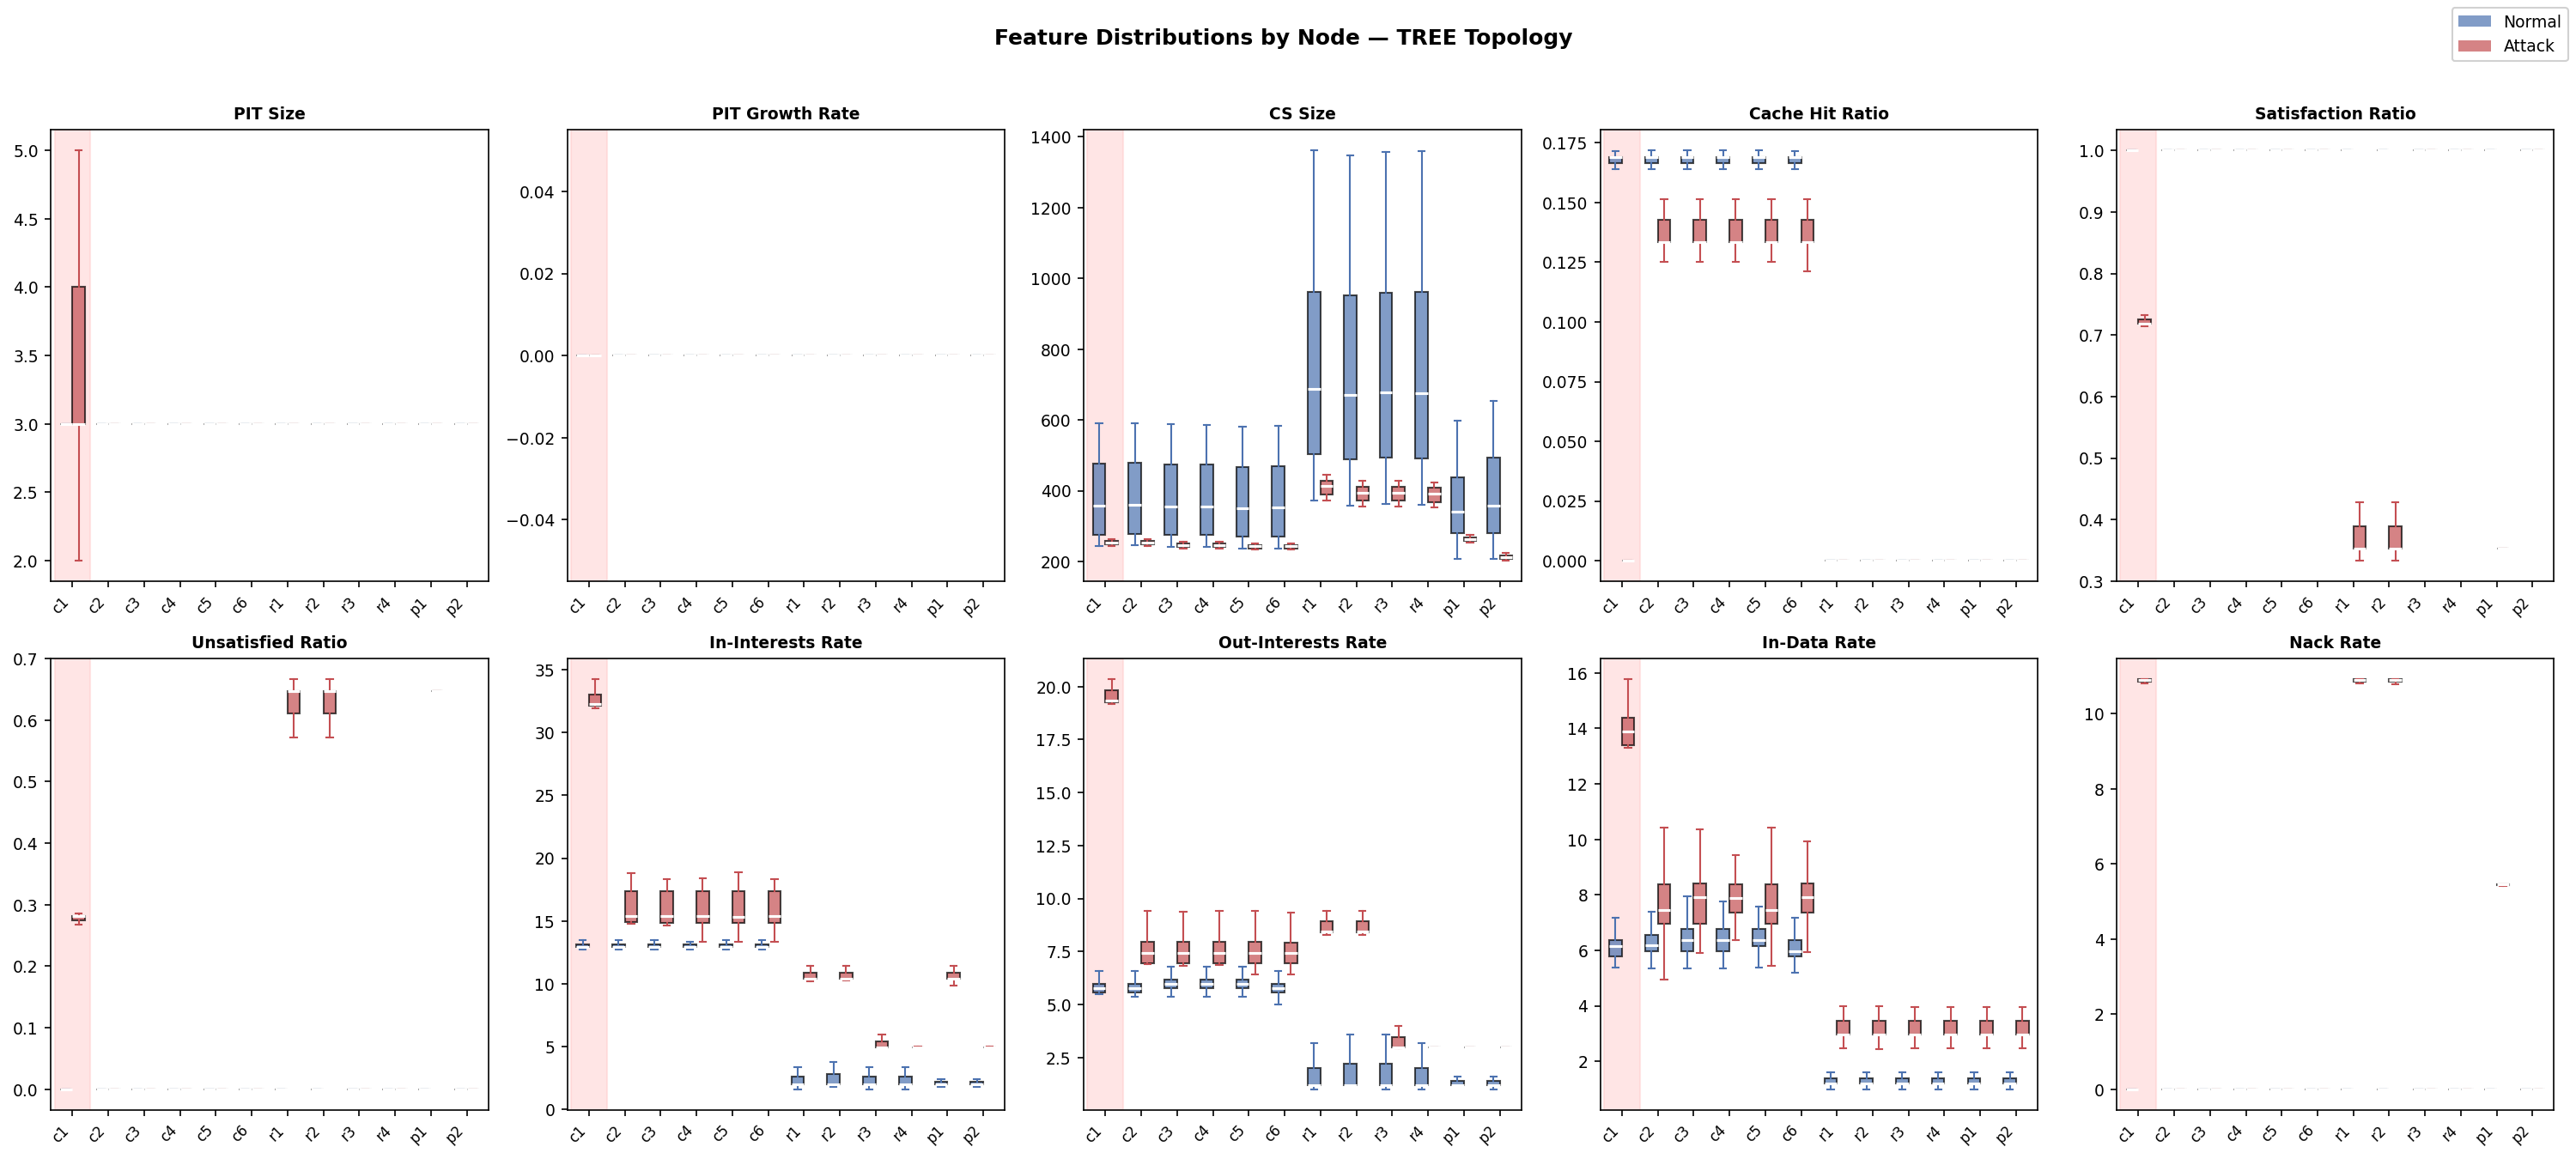

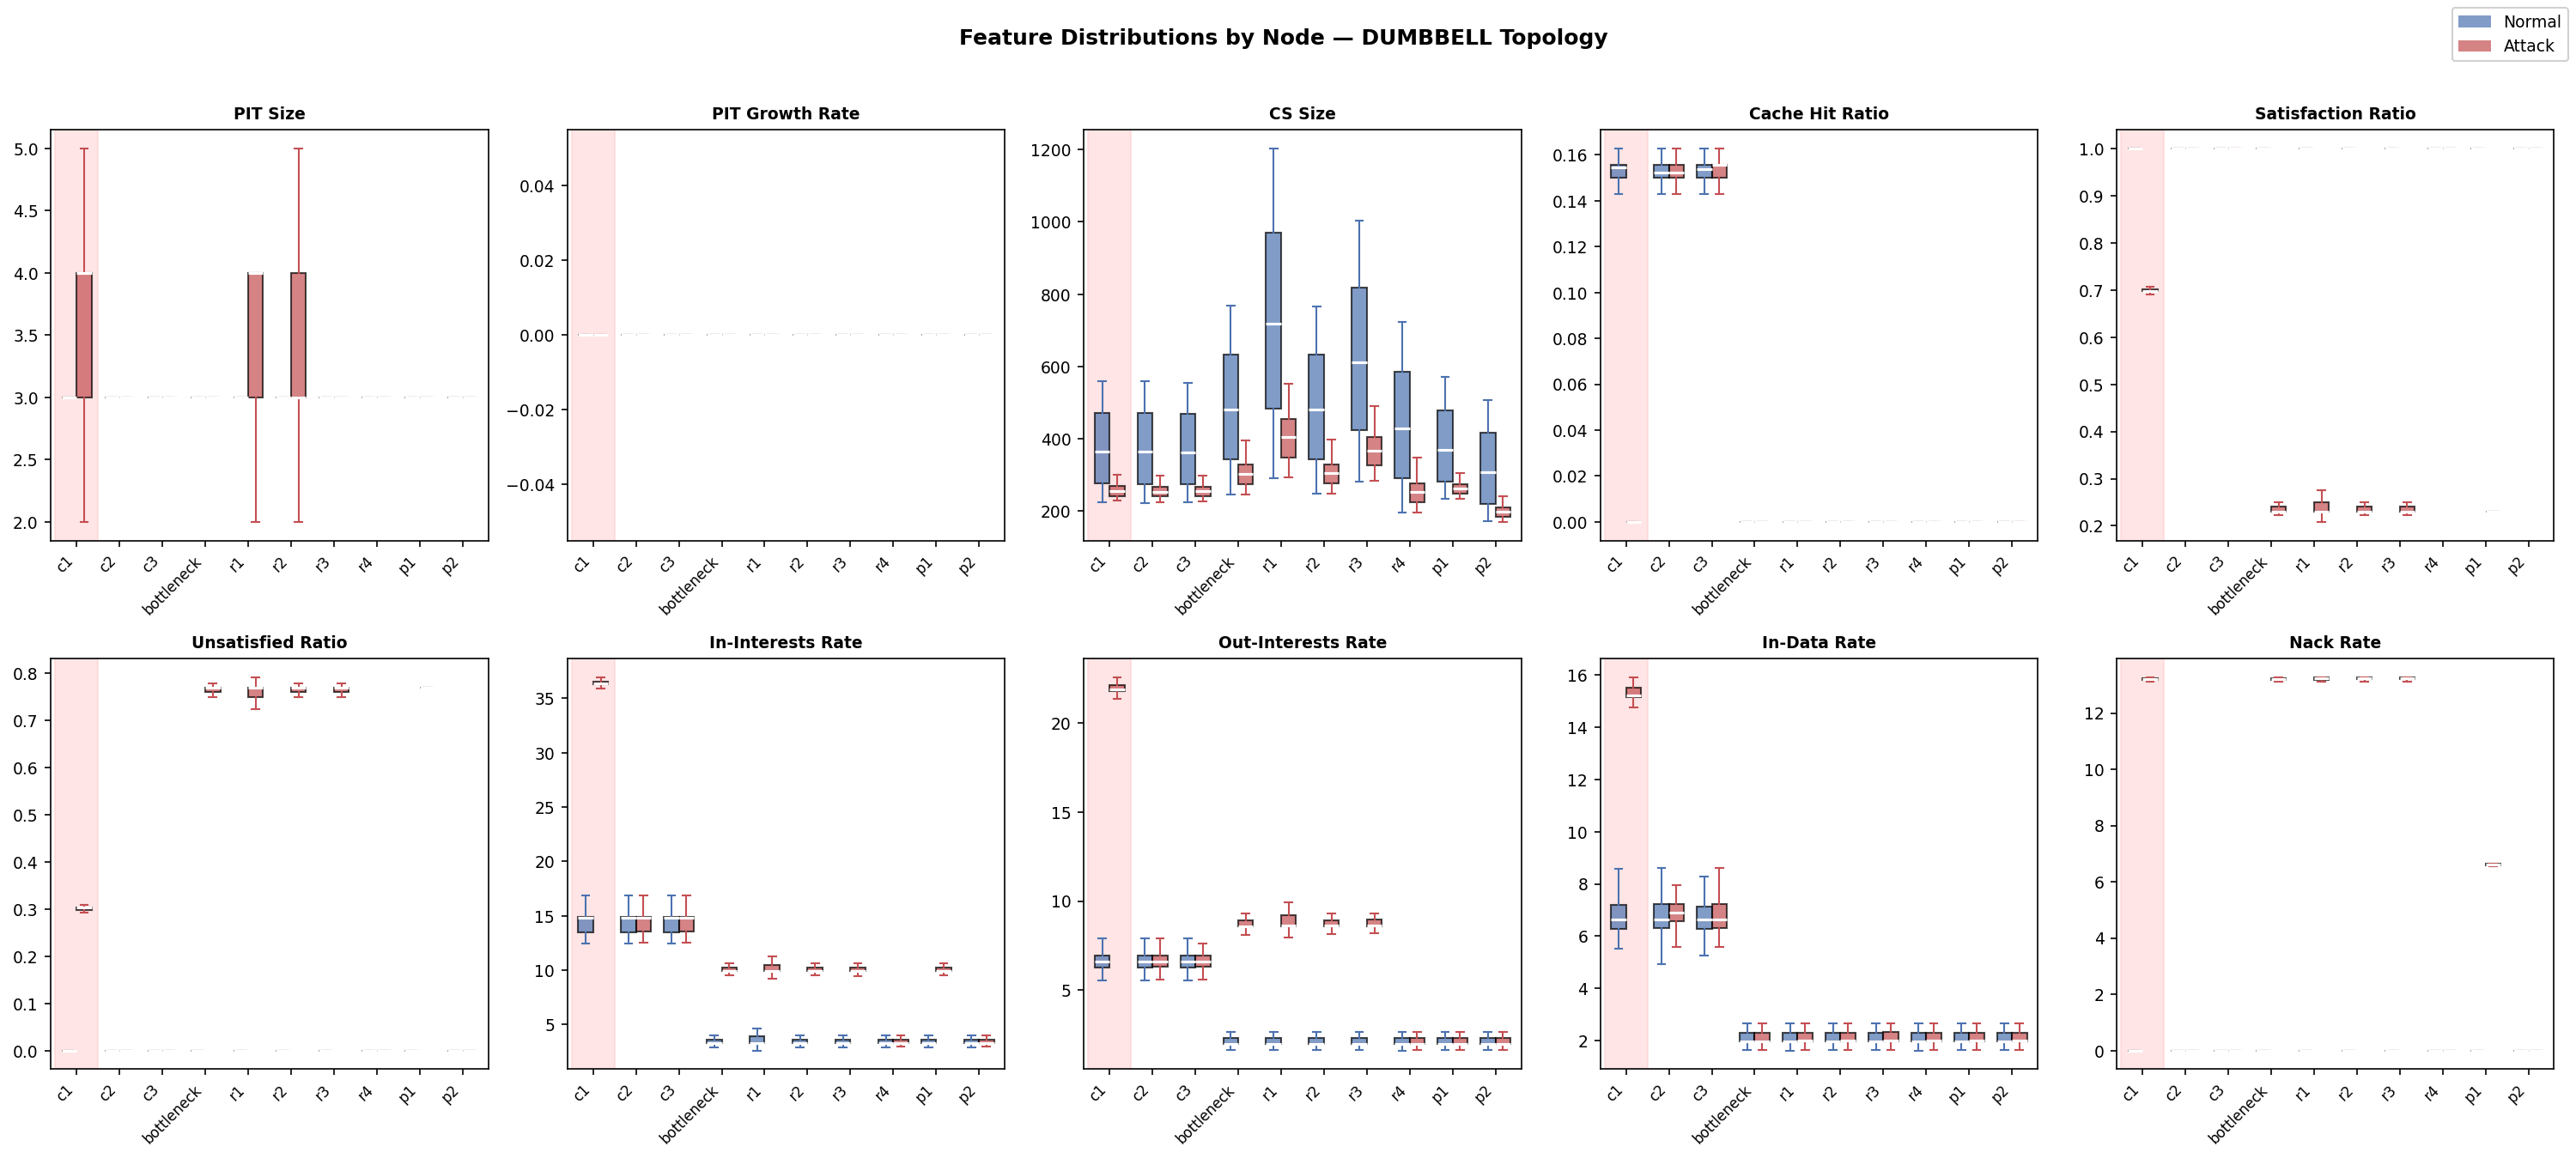

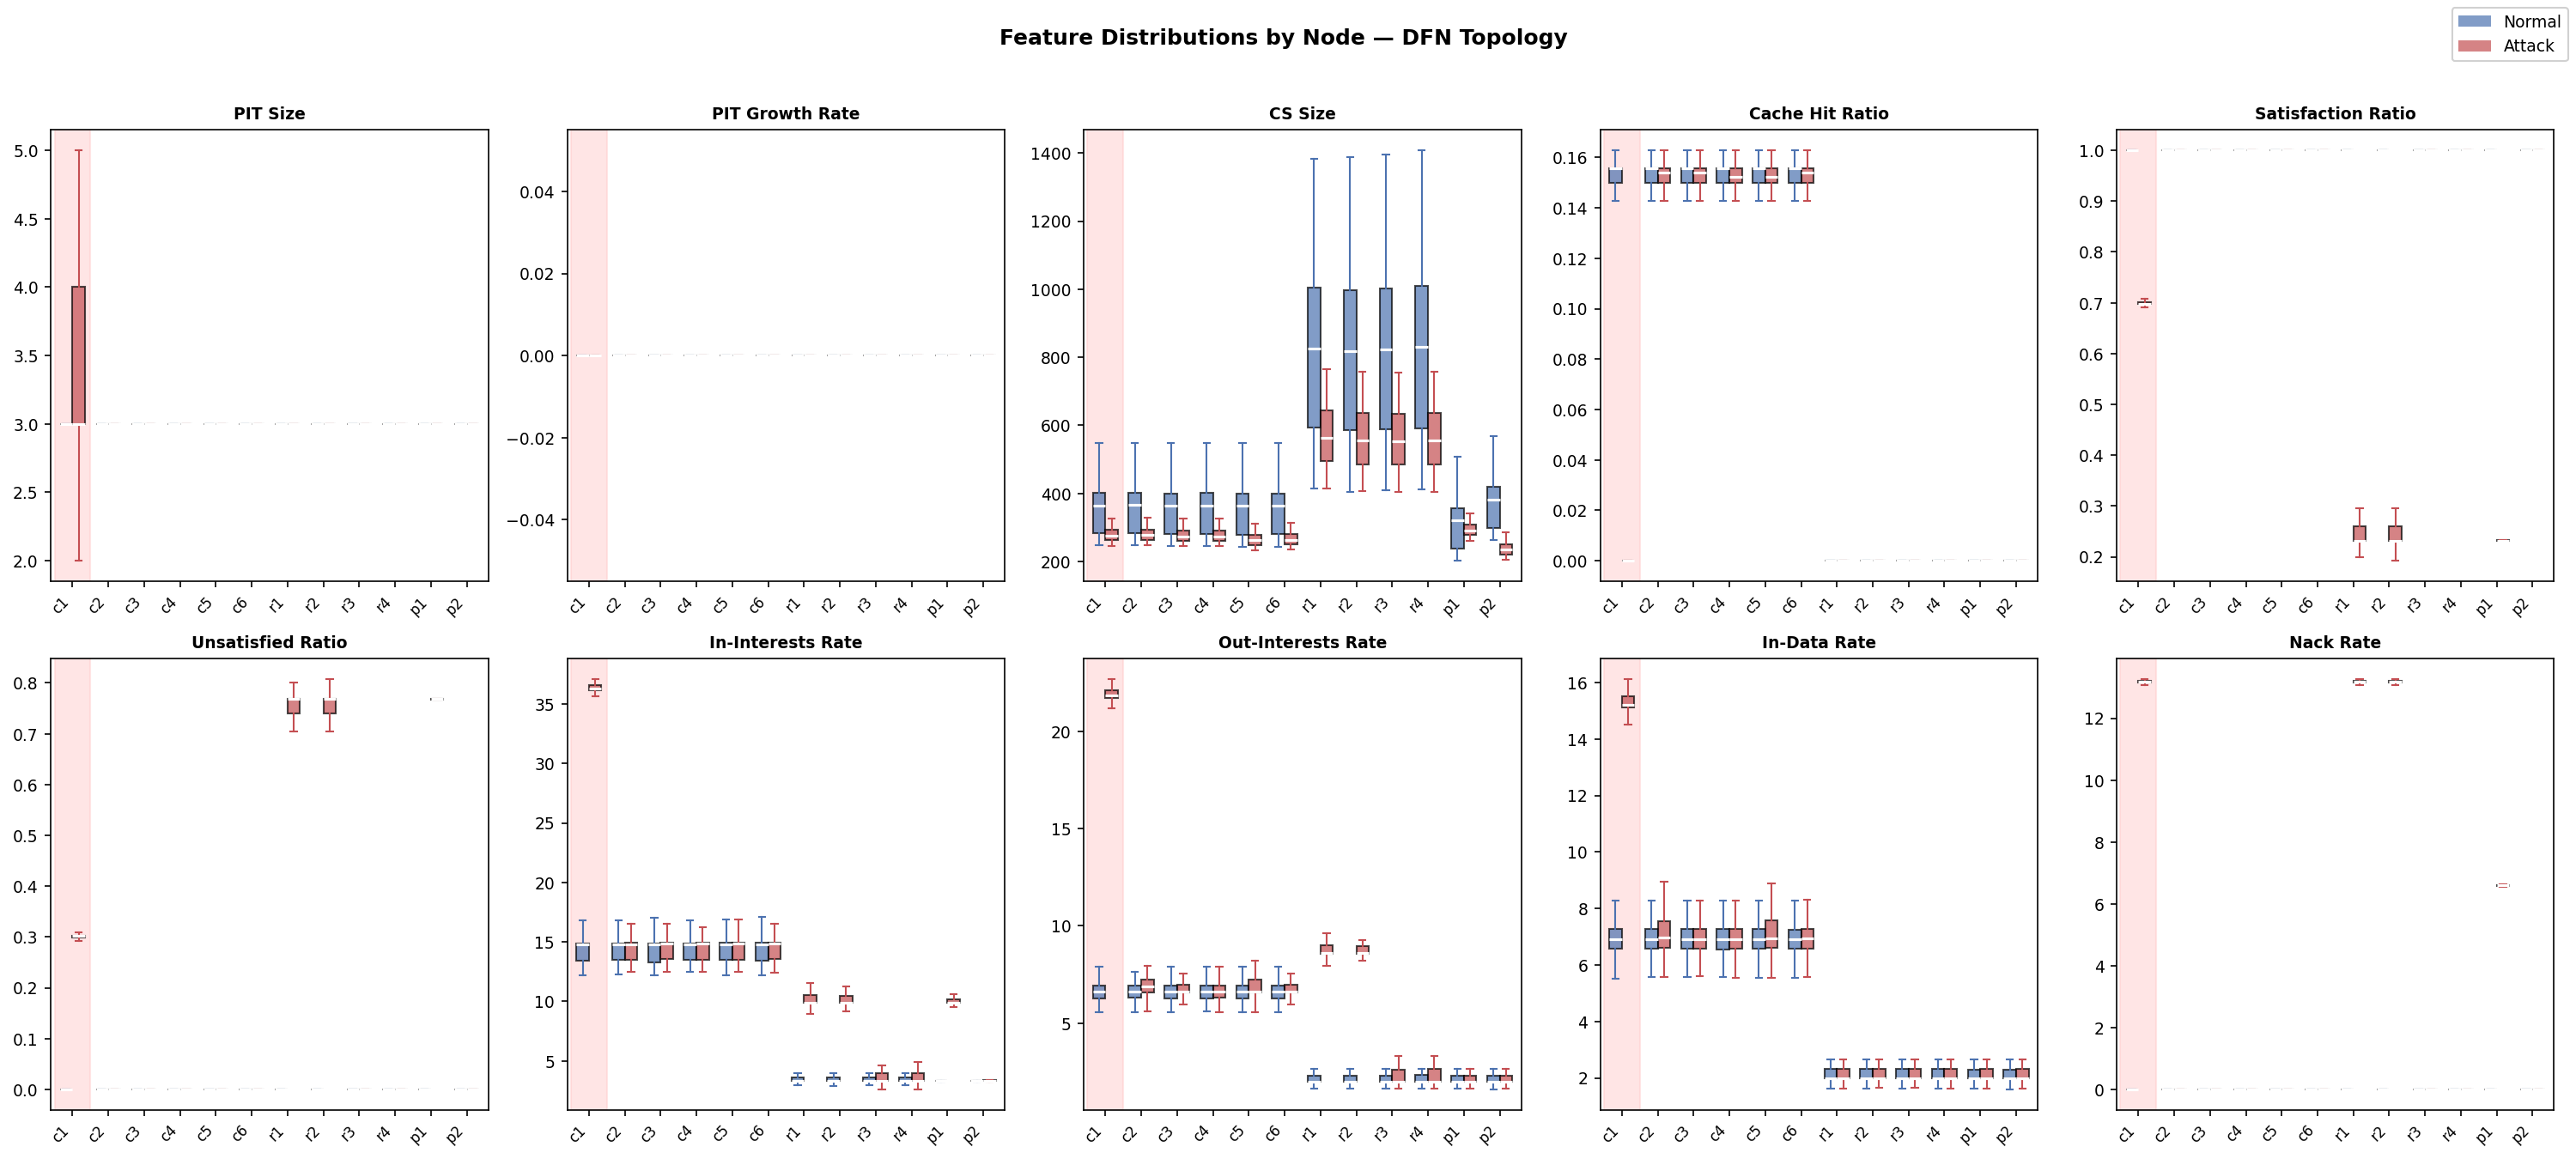

In [6]:
def plot_boxplots(topo):
    d = data[topo]
    nodes = d["nodes"]
    df_norm = d["normal"]
    df_atk = d["attack"]

    n_feats = len(FEATURES)
    n_cols = 5
    n_rows = 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 9))
    axes = axes.flatten()

    x_positions = np.arange(len(nodes))
    width = 0.35

    for fi, feat in enumerate(FEATURES):
        ax = axes[fi]

        if ATTACKER in nodes:
            att_idx = nodes.index(ATTACKER)
            ax.axvspan(att_idx - 0.5, att_idx + 0.5, color="#ffcccc", alpha=0.5, zorder=0)

        norm_data = [df_norm[df_norm["node"] == n][feat].dropna().values for n in nodes]
        atk_data = [df_atk[df_atk["node"] == n][feat].dropna().values for n in nodes]

        bp_norm = ax.boxplot(
            norm_data,
            positions=x_positions - width / 2,
            widths=width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="#4c72b0", alpha=0.7),
            medianprops=dict(color="white", linewidth=1.5),
            whiskerprops=dict(color="#4c72b0"),
            capprops=dict(color="#4c72b0")
        )

        bp_atk = ax.boxplot(
            atk_data,
            positions=x_positions + width / 2,
            widths=width,
            patch_artist=True,
            showfliers=False,
            boxprops=dict(facecolor="#c44e52", alpha=0.7),
            medianprops=dict(color="white", linewidth=1.5),
            whiskerprops=dict(color="#c44e52"),
            capprops=dict(color="#c44e52")
        )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(nodes, rotation=45, ha="right", fontsize=8)
        ax.set_title(FEAT_LABELS[feat], fontsize=9, fontweight="bold")
        ax.set_xlim(-0.6, len(nodes) - 0.4)

    legend_patches = [
        Patch(facecolor="#4c72b0", alpha=0.7, label="Normal"),
        Patch(facecolor="#c44e52", alpha=0.7, label="Attack")
    ]
    fig.legend(handles=legend_patches, loc="upper right", fontsize=9, framealpha=0.9)
    fig.suptitle(f"Feature Distributions by Node — {topo.upper()} Topology", fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(FIG_DIR / f"fig_boxplots_{topo}.png", bbox_inches="tight")
    plt.show()


for topo in data:
    plot_boxplots(topo)

## 3. Feature Correlations

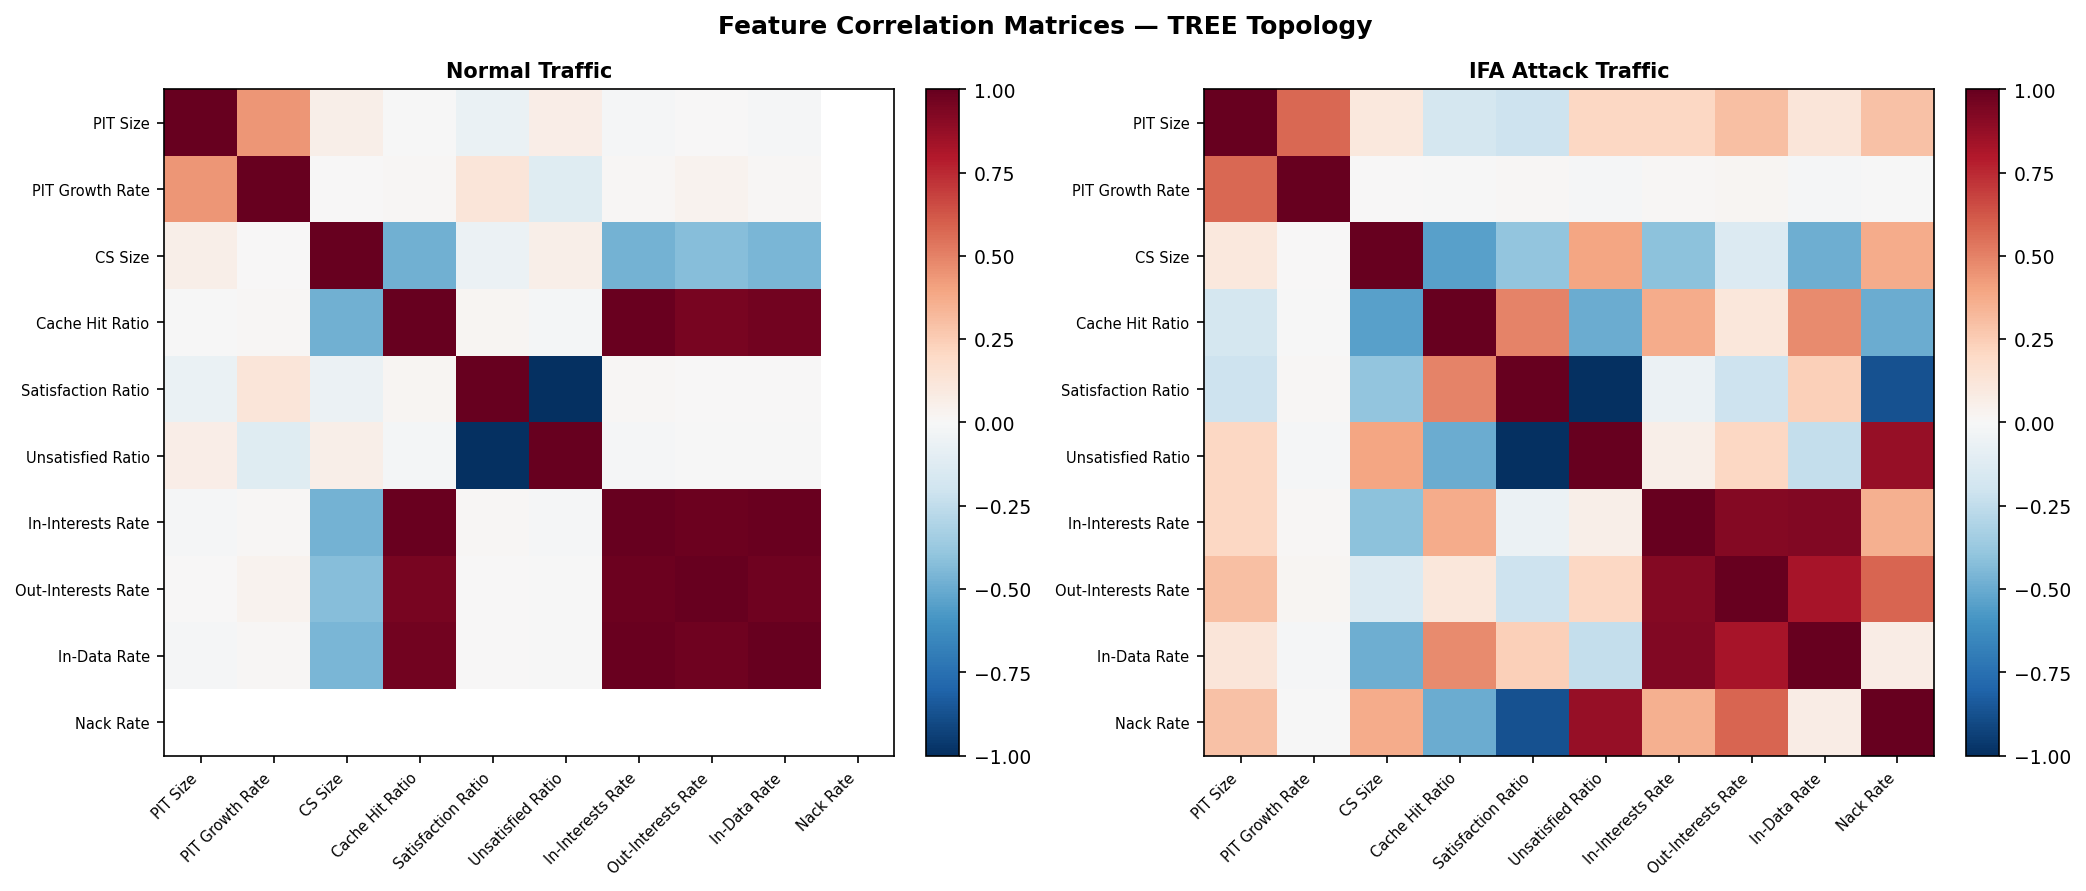

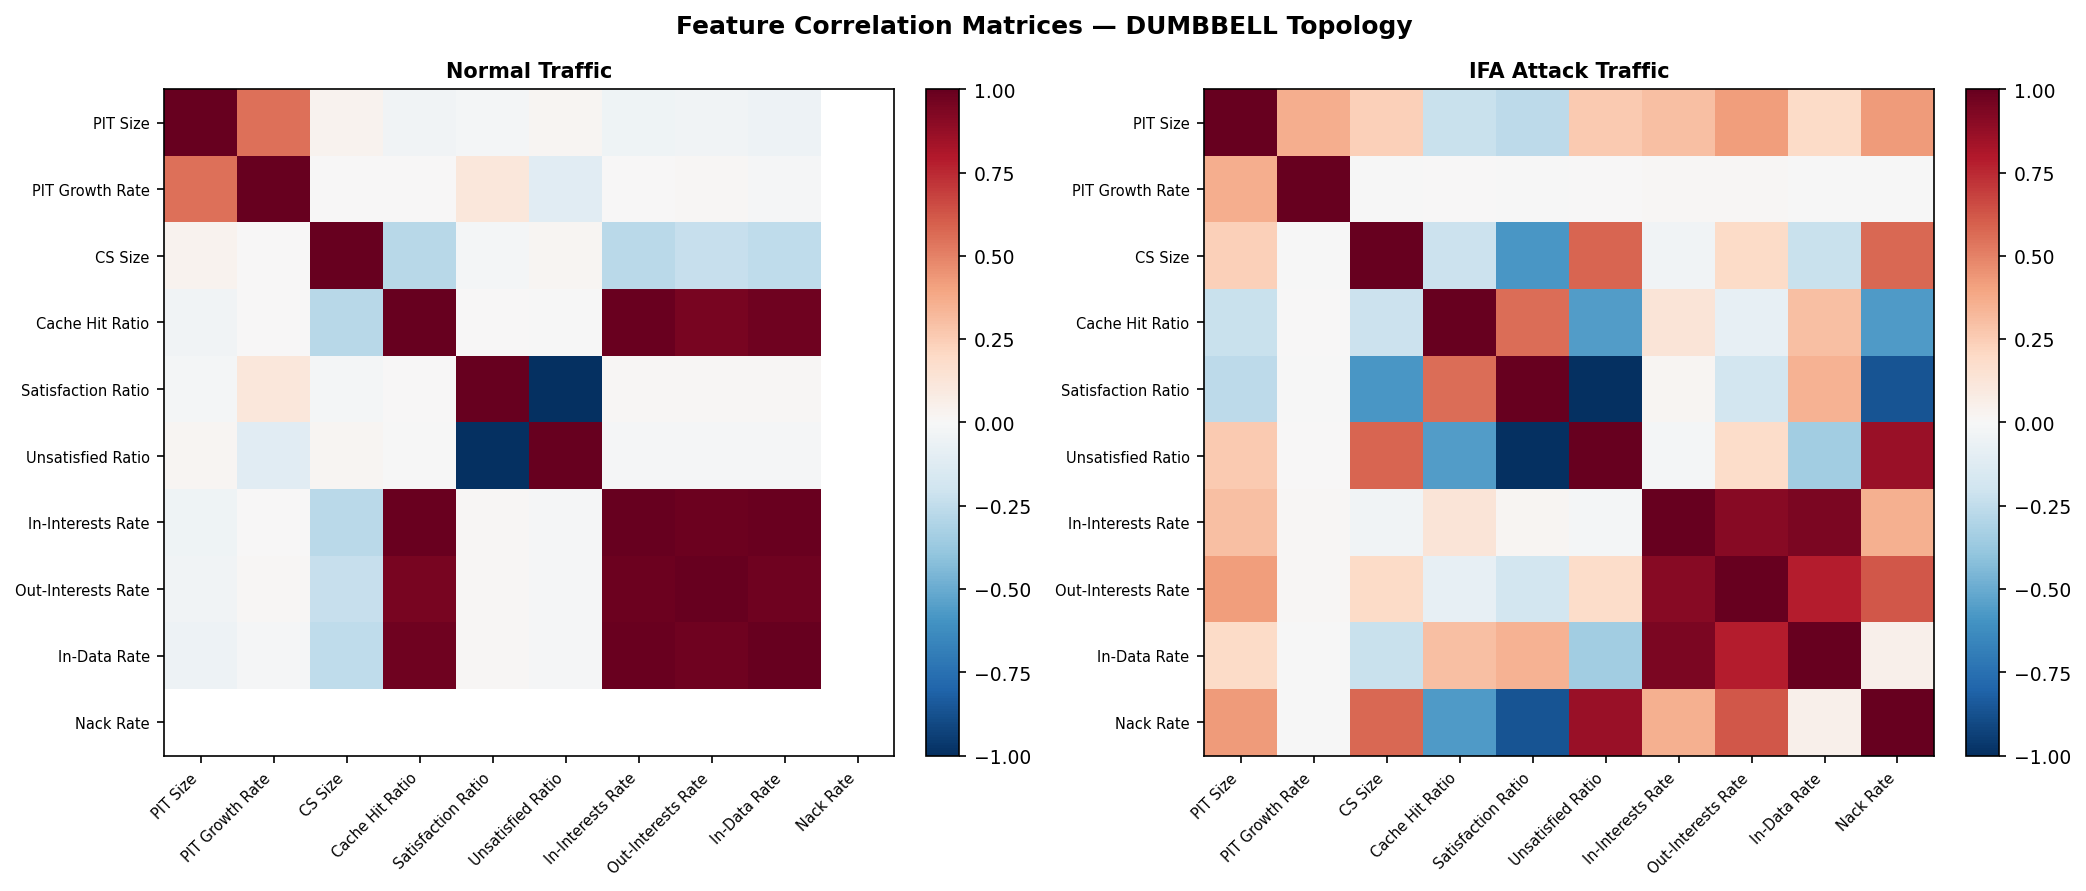

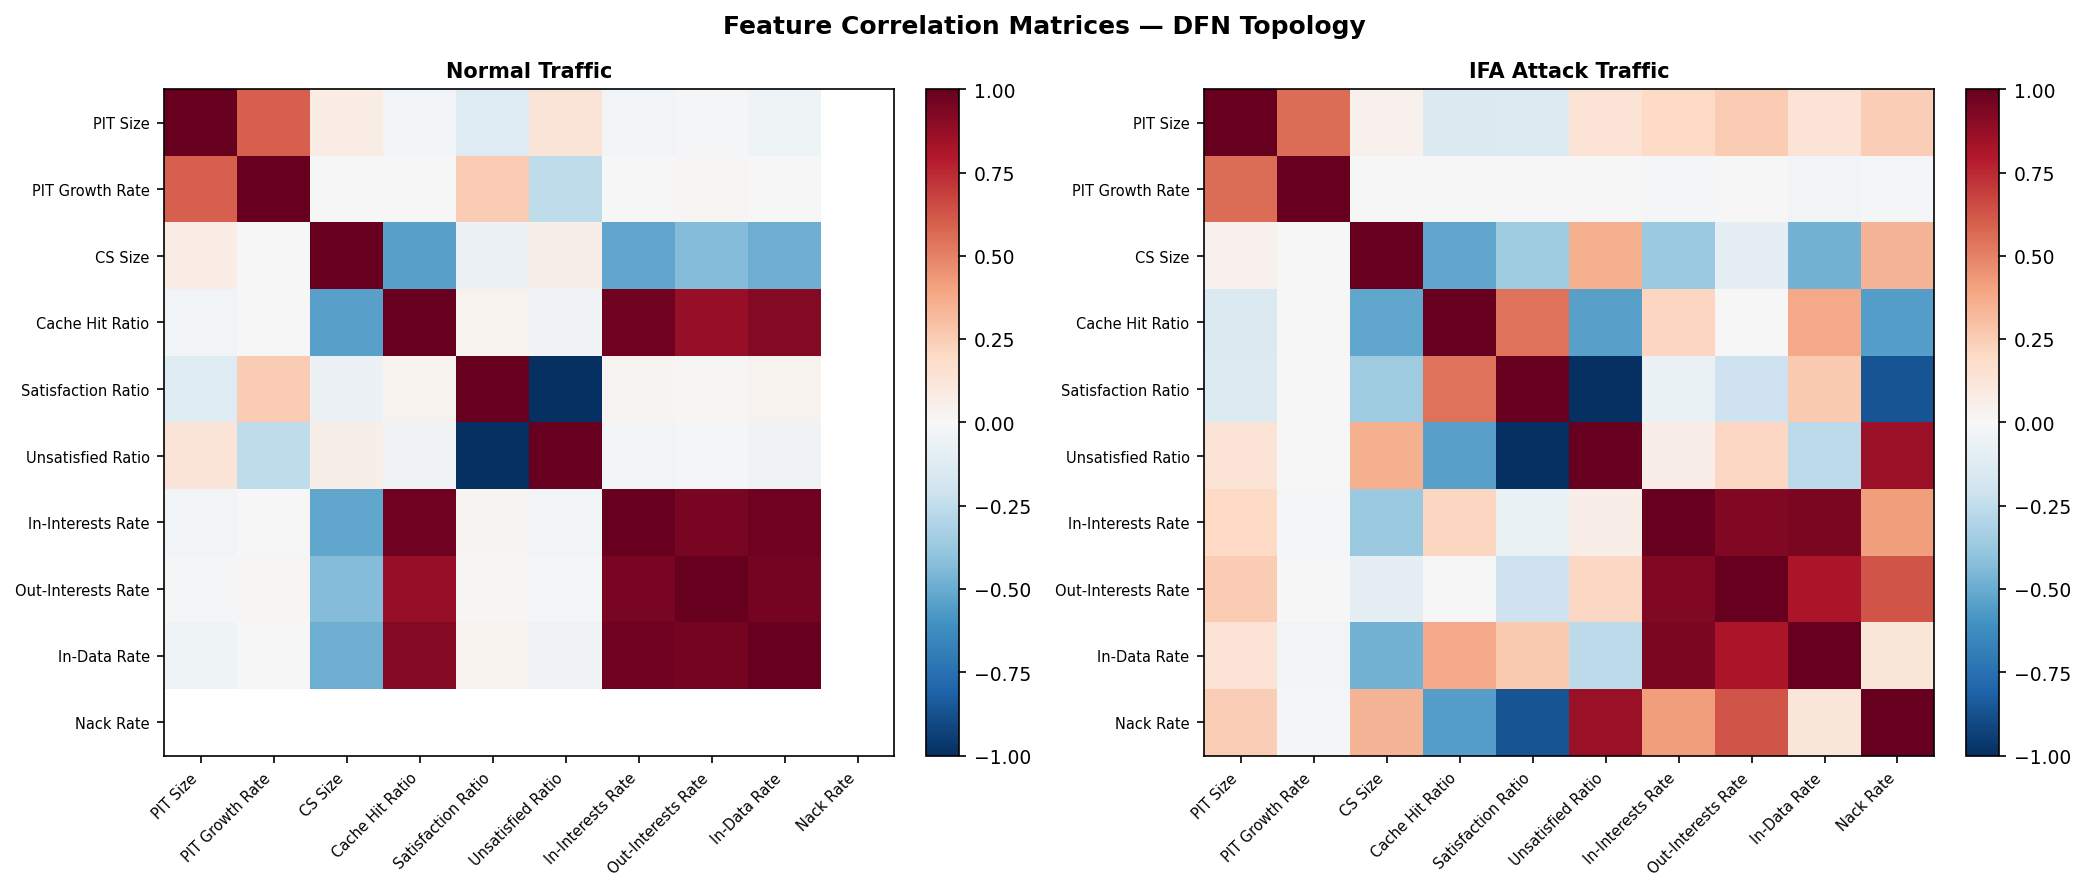

In [7]:
def plot_correlations(topo):
    d = data[topo]
    corr_norm = d["normal"][FEATURES].corr()
    corr_atk = d["attack"][FEATURES].corr()

    labels = [FEAT_LABELS[f] for f in FEATURES]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, corr_mat, title in [
        (axes[0], corr_norm, "Normal Traffic"),
        (axes[1], corr_atk, "IFA Attack Traffic")
    ]:
        im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(FEATURES)))
        ax.set_yticks(range(len(FEATURES)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        ax.set_yticklabels(labels, fontsize=7)
        ax.set_title(title, fontsize=10, fontweight="bold")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Feature Correlation Matrices — {topo.upper()} Topology", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_correlation_{topo}.png", bbox_inches="tight")
    plt.show()


for topo in data:
    plot_correlations(topo)

## 4. Attack Onset Time-Series

Key features over time for the attacker (c1), a benign consumer (c2), and a backbone router (r1).
IFA data starts from t=0 with the attack already active.

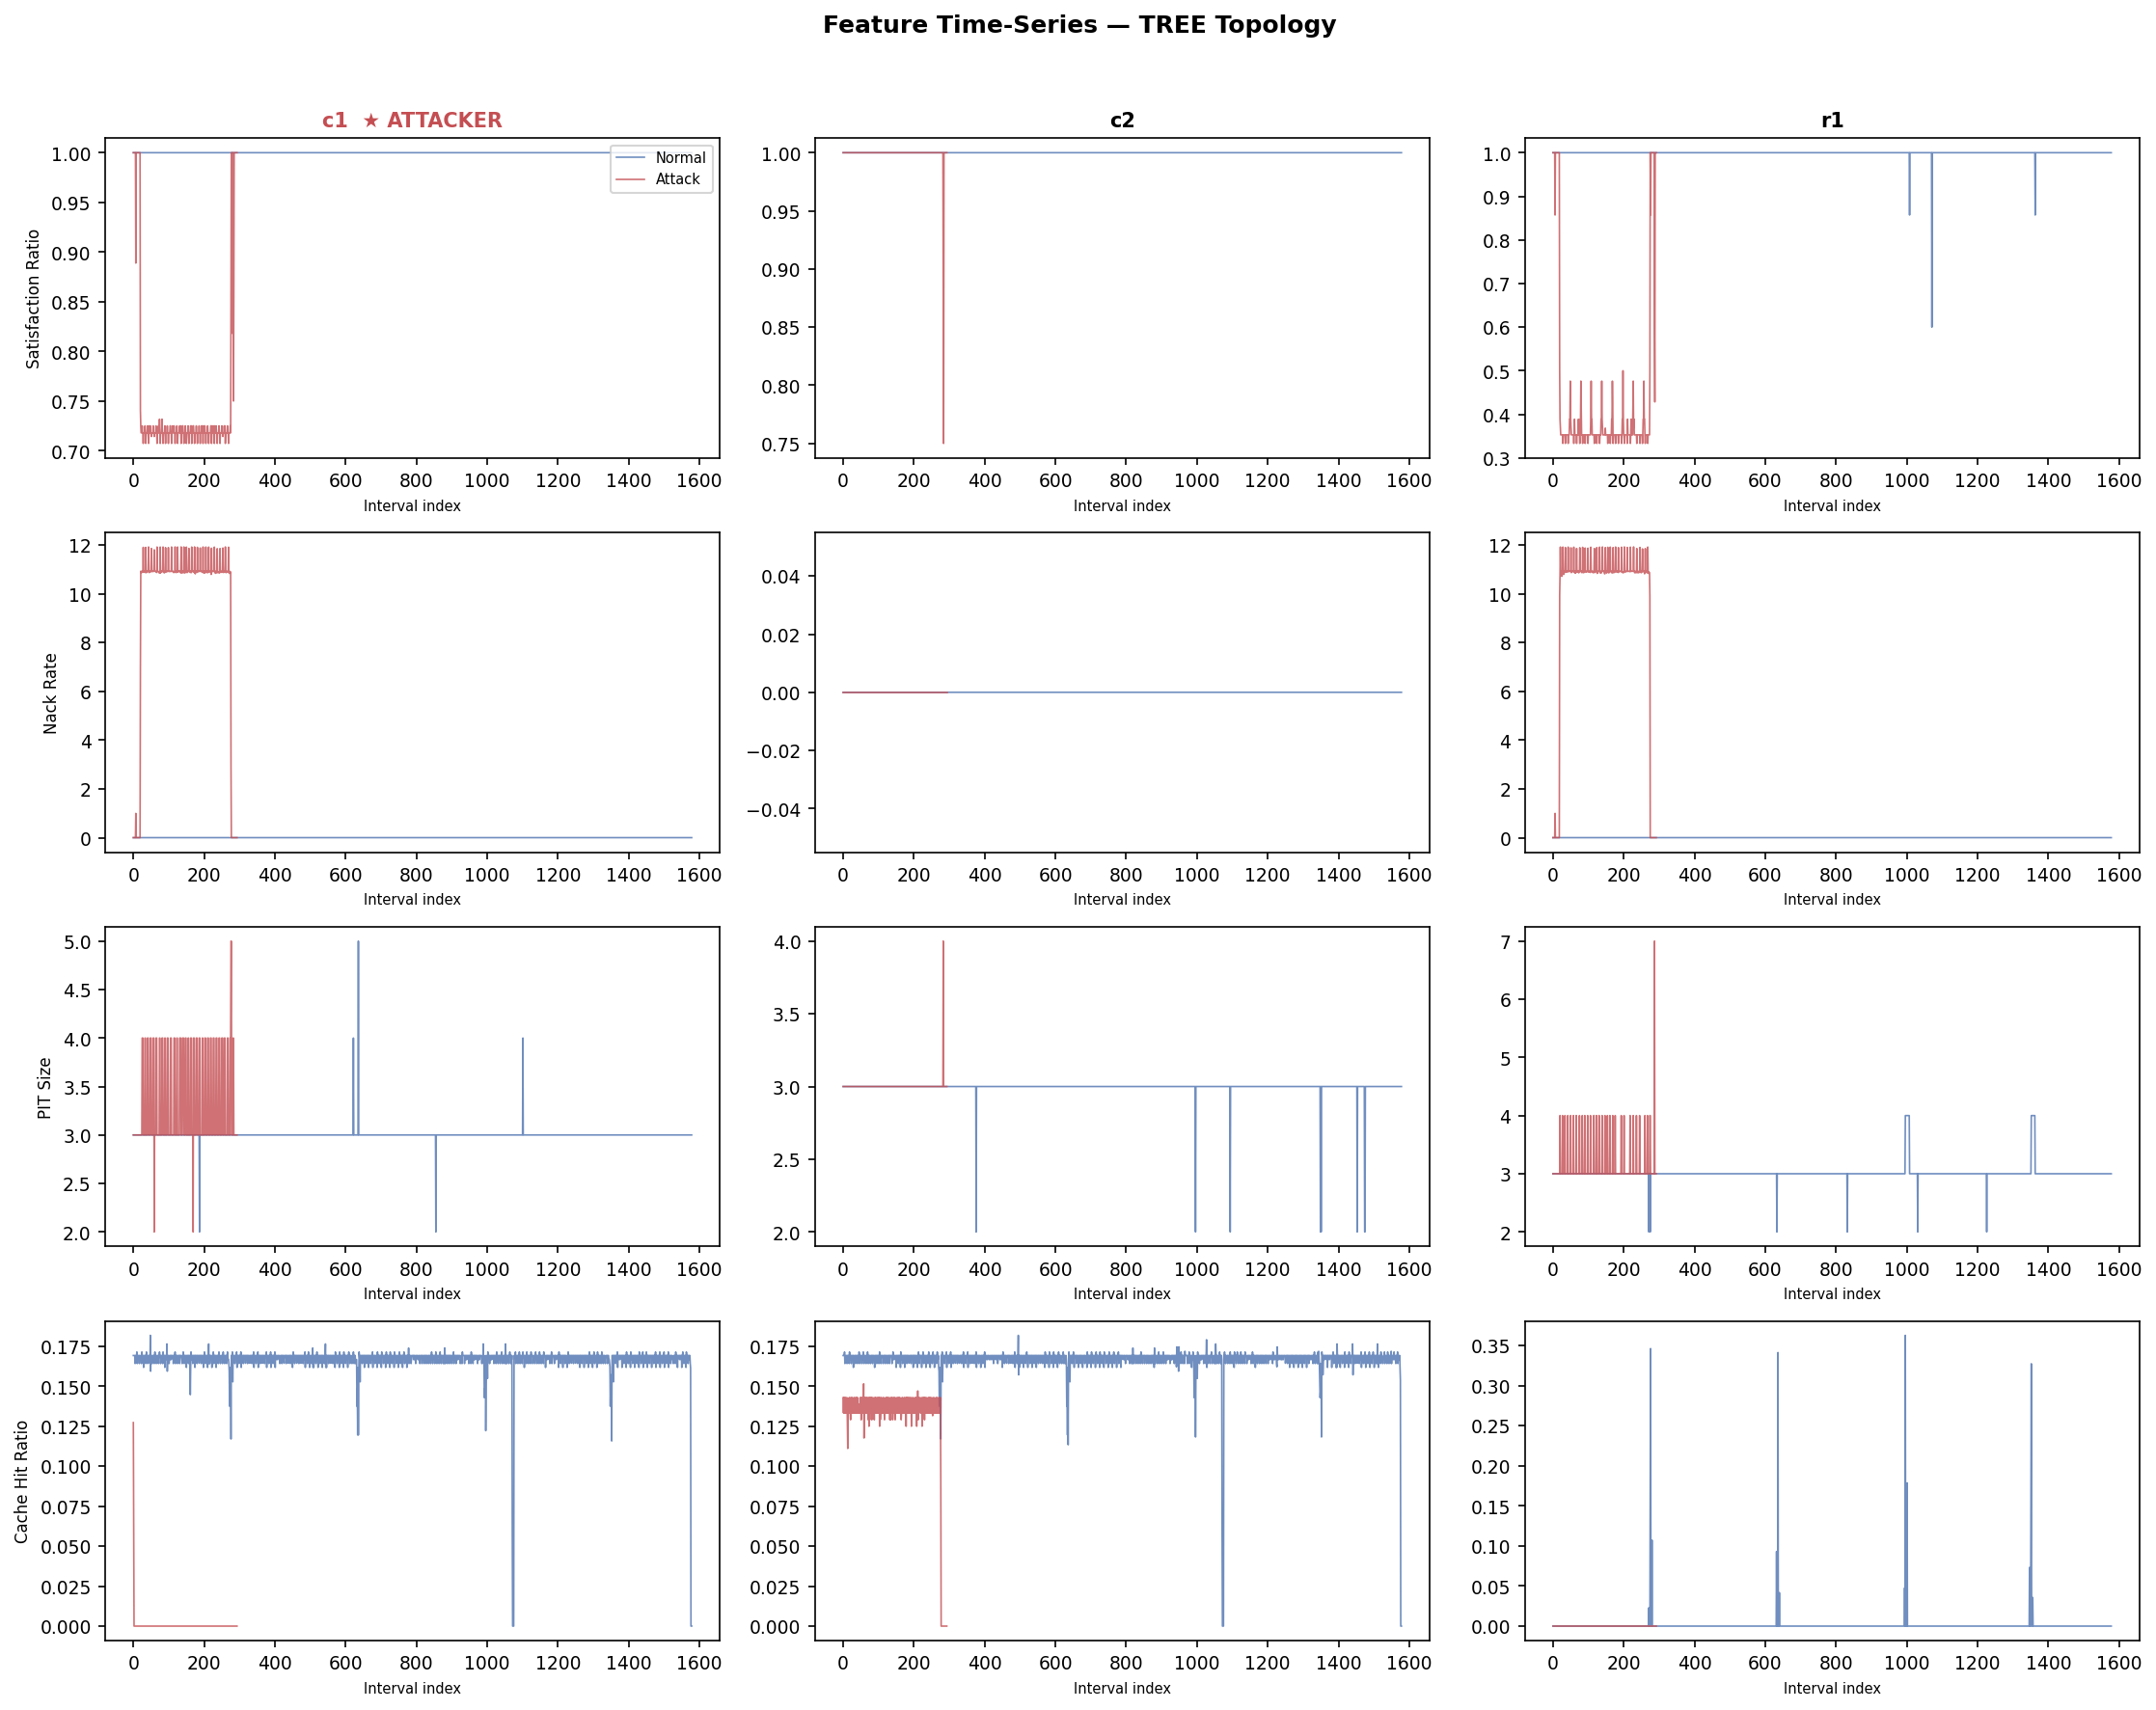

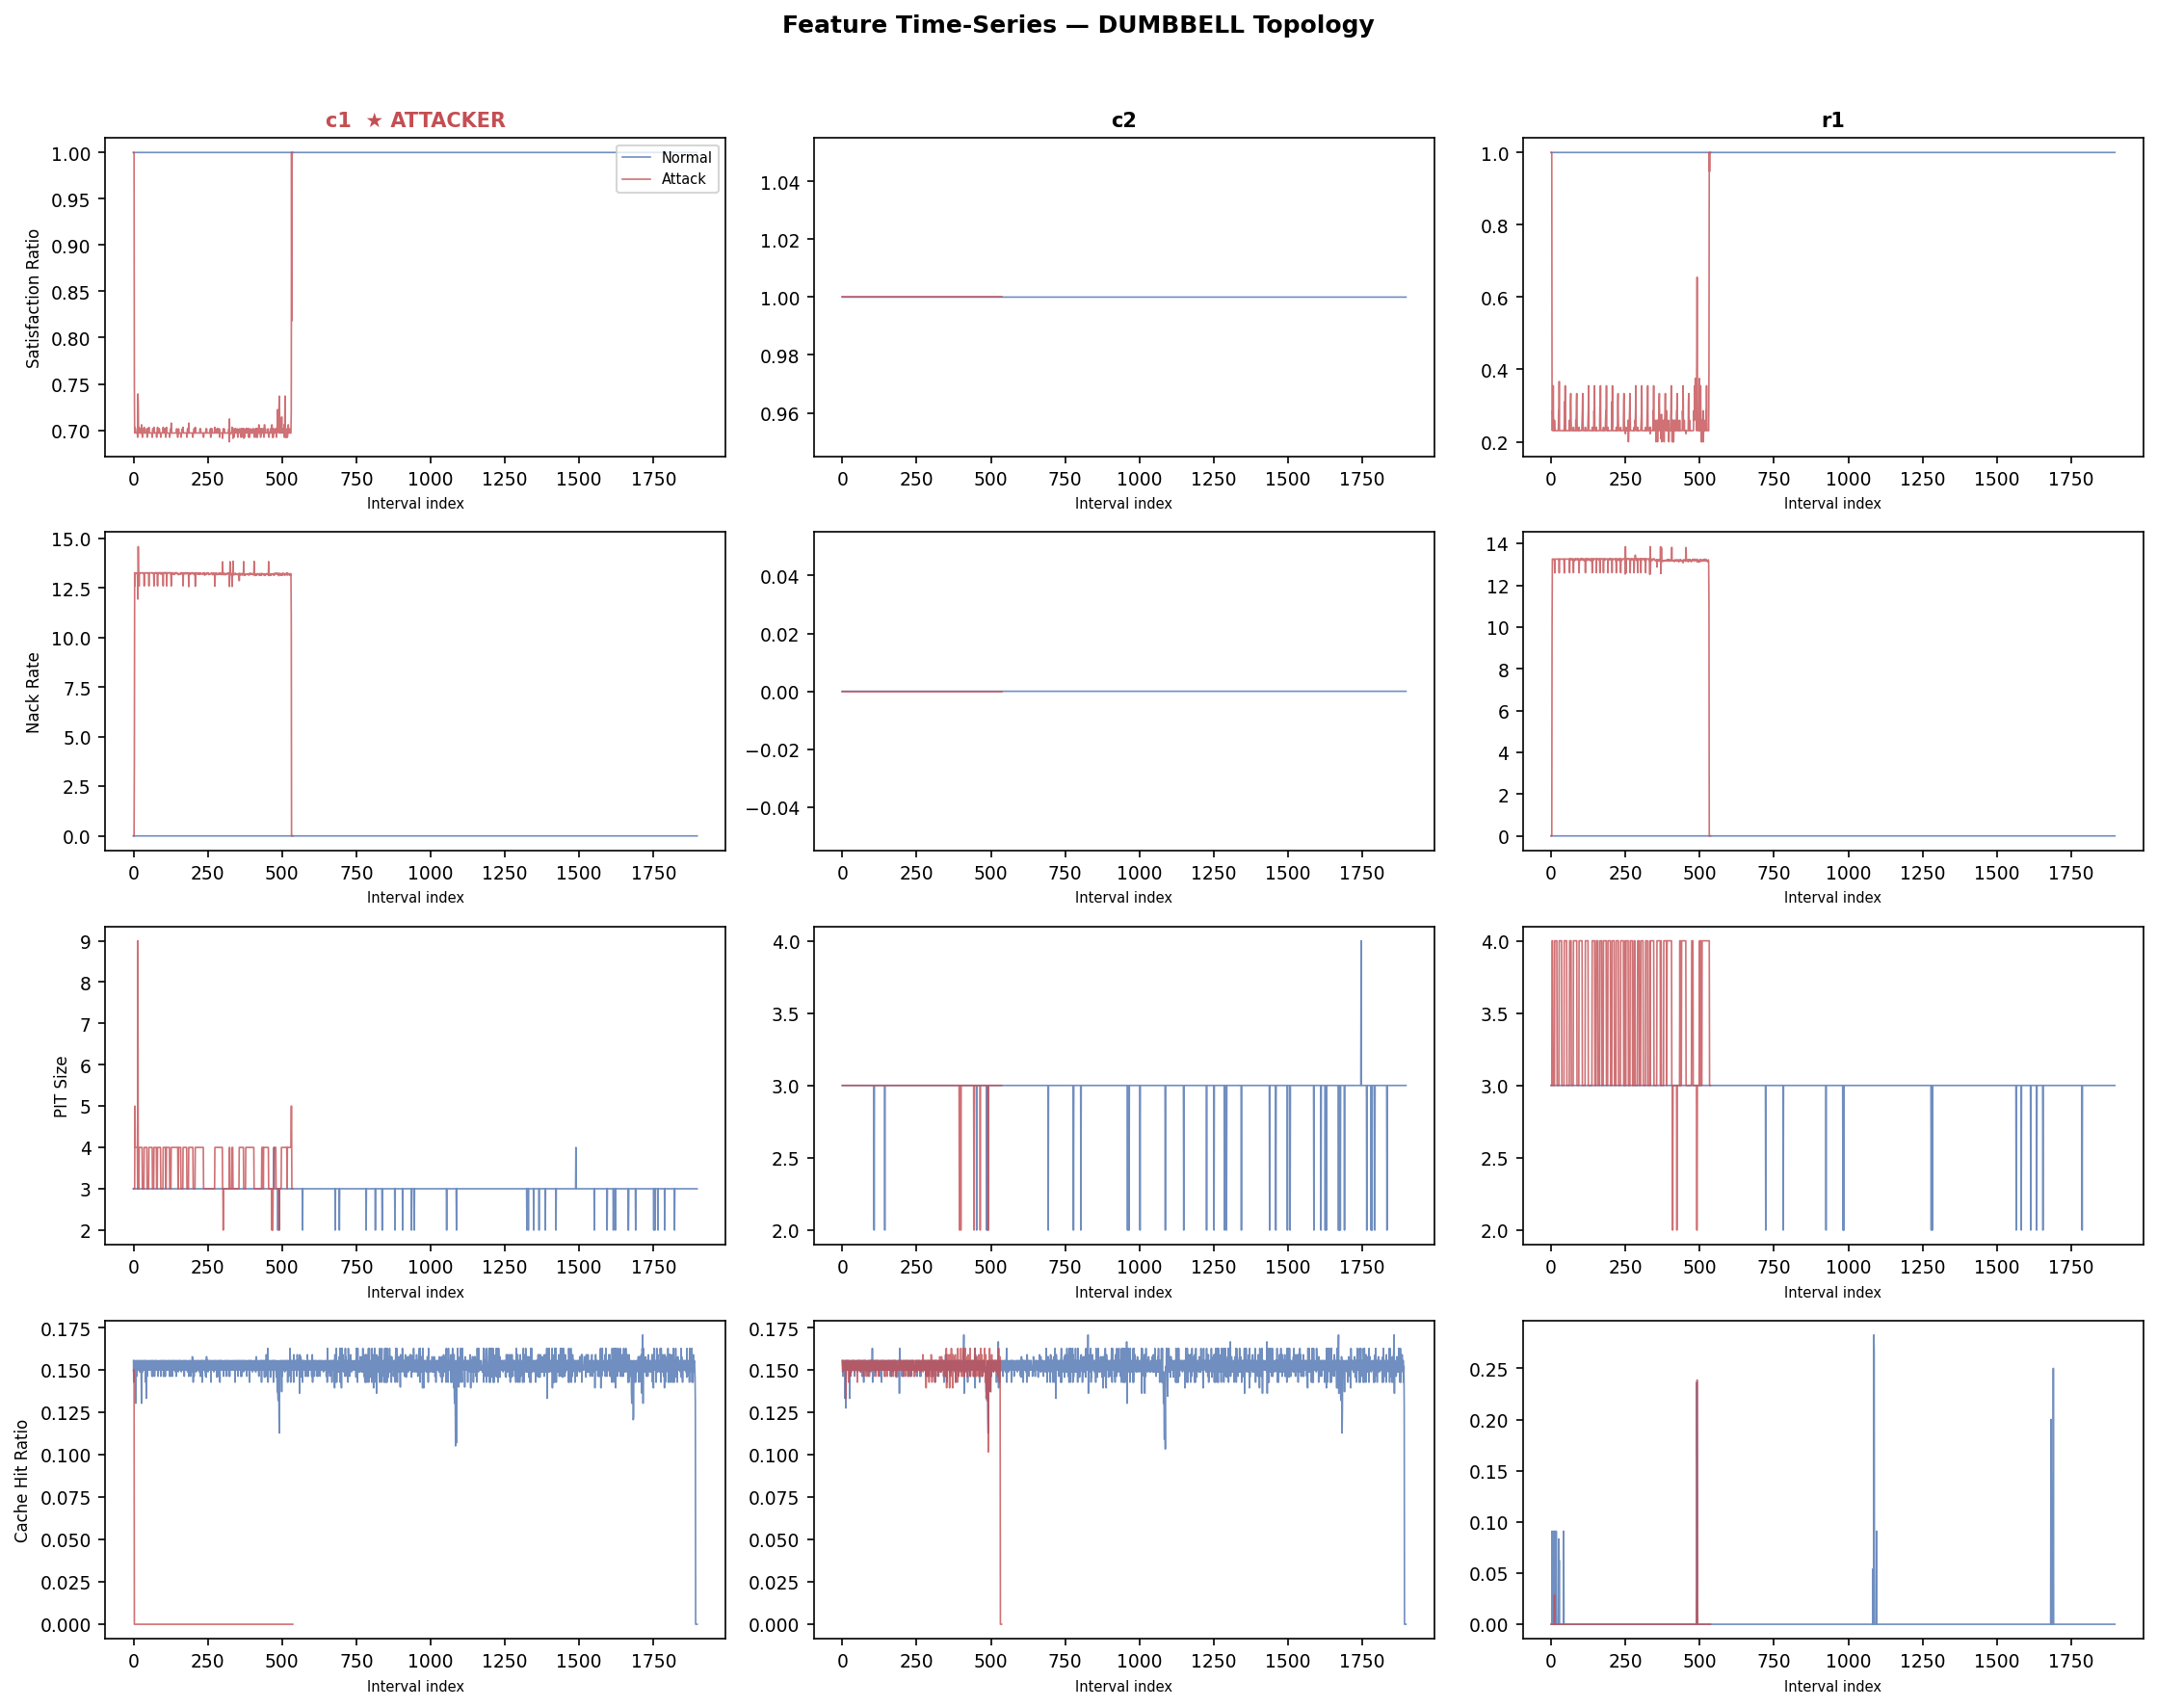

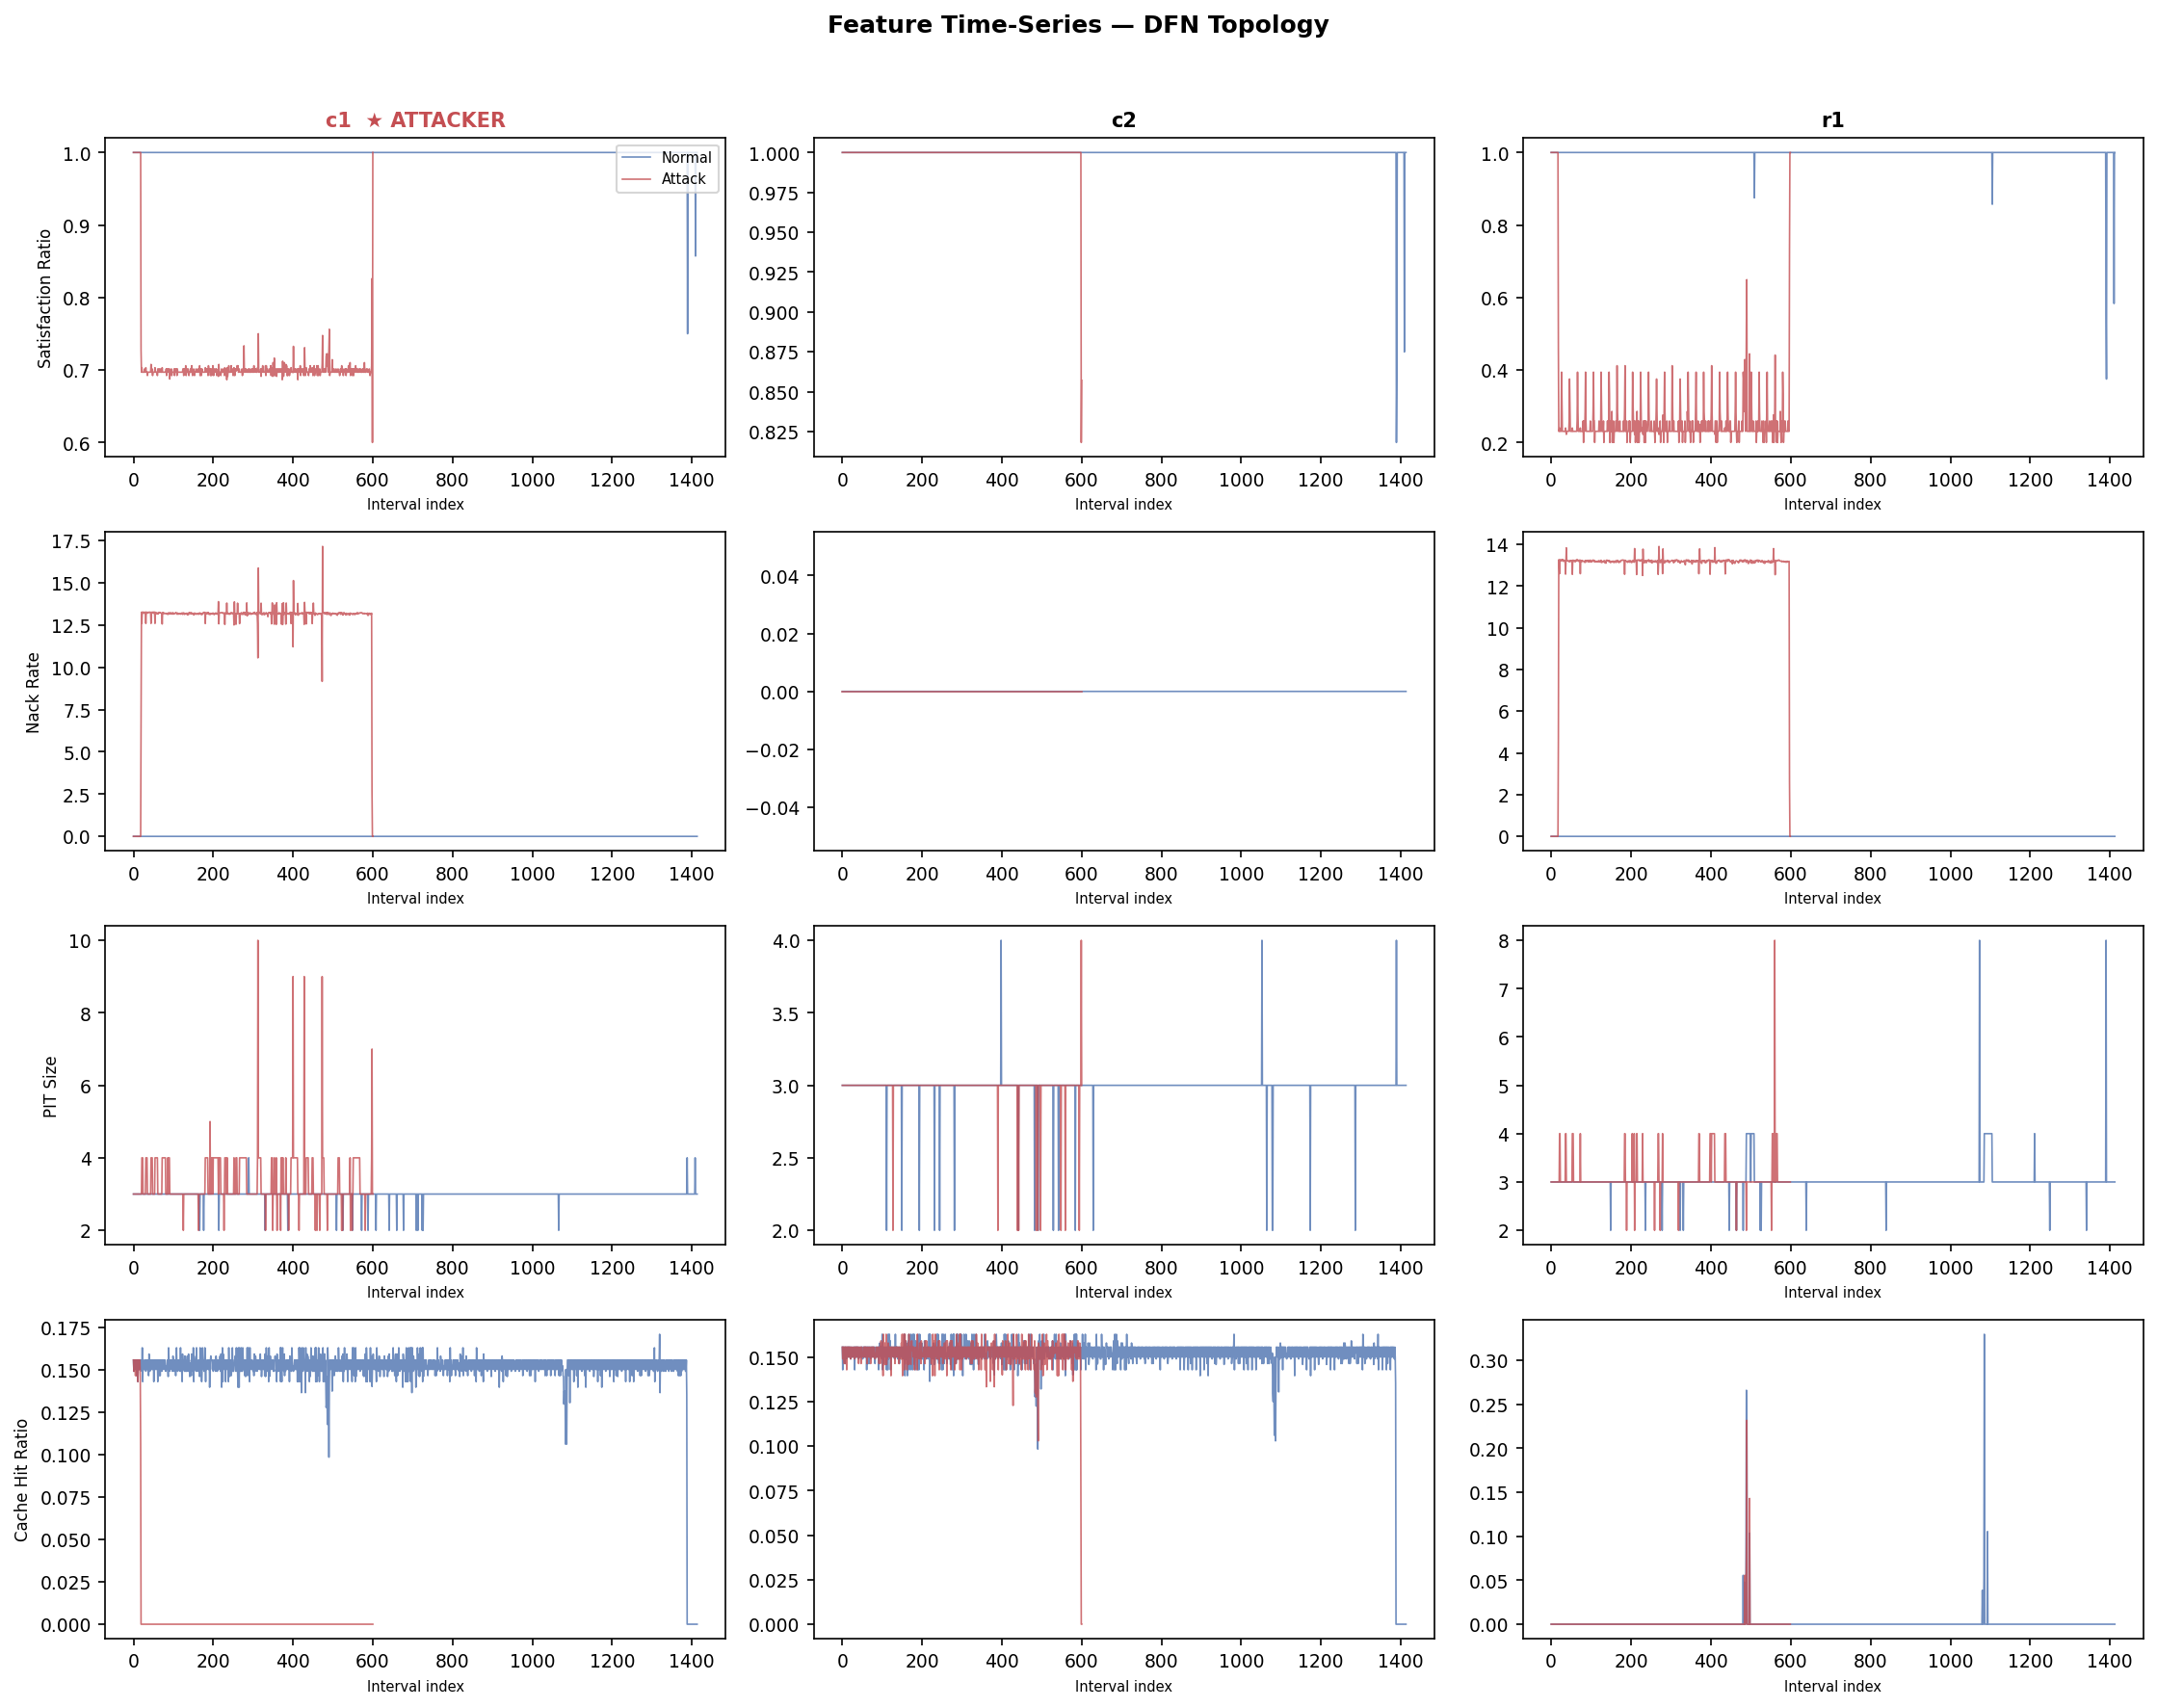

In [8]:
def plot_timeseries(topo):
    d = data[topo]
    df_norm = d["normal"]
    df_atk = d["attack"]

    key_feats = ["satisfaction_ratio", "nack_rate", "pit_size", "cache_hit_ratio"]
    candidate_nodes = ["c1", "c2", "r1"]
    all_nodes = set(df_norm["node"].unique()) | set(df_atk["node"].unique())
    nodes_to_plot = [n for n in candidate_nodes if n in all_nodes]

    if not nodes_to_plot:
        print(f"No plottable nodes for {topo}")
        return

    n_rows = len(key_feats)
    n_cols = len(nodes_to_plot)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for ci, node in enumerate(nodes_to_plot):
        col_title = node
        if node == ATTACKER:
            col_title = f"{node}  ★ ATTACKER"
        axes[0, ci].set_title(col_title, fontsize=10, fontweight="bold",
                               color="#c44e52" if node == ATTACKER else "black")

        for ri, feat in enumerate(key_feats):
            ax = axes[ri, ci]

            norm_node = df_norm[df_norm["node"] == node][feat].dropna().values
            atk_node = df_atk[df_atk["node"] == node][feat].dropna().values

            if len(norm_node) > 0:
                ax.plot(range(len(norm_node)), norm_node, color="#4c72b0", alpha=0.8,
                        linewidth=0.8, label="Normal")
            if len(atk_node) > 0:
                ax.plot(range(len(atk_node)), atk_node, color="#c44e52", alpha=0.8,
                        linewidth=0.8, label="Attack")

            ax.set_xlabel("Interval index", fontsize=7)
            if ci == 0:
                ax.set_ylabel(FEAT_LABELS[feat], fontsize=8)

            if ri == 0 and ci == 0:
                ax.legend(fontsize=7, loc="upper right")

    fig.suptitle(f"Feature Time-Series — {topo.upper()} Topology", fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(FIG_DIR / f"fig_timeseries_{topo}.png", bbox_inches="tight")
    plt.show()


for topo in data:
    plot_timeseries(topo)

## 5. Kolmogorov-Smirnov Statistical Separation

The KS test measures the maximum distance between the empirical CDFs of two distributions:
- **D-statistic ≈ 1** — perfect separation between normal and attack distributions
- **D-statistic ≈ 0** — no discernible separation

High D-values indicate features that are most useful for distinguishing normal from attack traffic.

In [9]:
ks_rows = []

for topo, d in data.items():
    df_norm = d["normal"]
    df_atk = d["attack"]
    nodes = d["nodes"]

    for node in nodes:
        for feat in FEATURES:
            norm_vals = df_norm[df_norm["node"] == node][feat].dropna().values
            atk_vals = df_atk[df_atk["node"] == node][feat].dropna().values

            if len(norm_vals) < 2 or len(atk_vals) < 2:
                ks_stat, p_val = np.nan, np.nan
            else:
                ks_stat, p_val = ks_2samp(norm_vals, atk_vals)

            ks_rows.append({
                "topology": topo,
                "node": node,
                "feature": feat,
                "ks_stat": ks_stat,
                "p_value": p_val
            })

df_ks = pd.DataFrame(ks_rows)
df_ks.to_csv(RESULTS_DIR / "ks_test_results.csv", index=False)
print(f"Saved KS results to {RESULTS_DIR / 'ks_test_results.csv'}")

print("\nTop 15 KS results for attacker node c1:")
df_ks[df_ks["node"] == ATTACKER].sort_values("ks_stat", ascending=False).head(15)

Saved KS results to /Users/ankitpokhrel/Desktop/minor_project_refactored/miniNDN/research_analysis/results/ks_test_results.csv

Top 15 KS results for attacker node c1:


,topology,node,feature,ks_stat,p_value
3,tree,c1,cache_hit_ratio,0.991767,3.458460e-323
123,dumbbell,c1,cache_hit_ratio,0.991252,2.470328e-323
125,dumbbell,c1,unsatisfied_ratio,0.986965,3.952525e-323
124,dumbbell,c1,satisfaction_ratio,0.986965,3.952525e-323
129,dumbbell,c1,nack_rate,0.985102,4.446591e-323
128,dumbbell,c1,in_data_rate,0.983240,4.940656e-323
127,dumbbell,c1,out_interests_rate,0.983240,4.940656e-323
126,dumbbell,c1,in_interests_rate,0.983240,4.940656e-323
225,dfn,c1,unsatisfied_ratio,0.966015,7.410985e-323
224,dfn,c1,satisfaction_ratio,0.966015,7.410985e-323


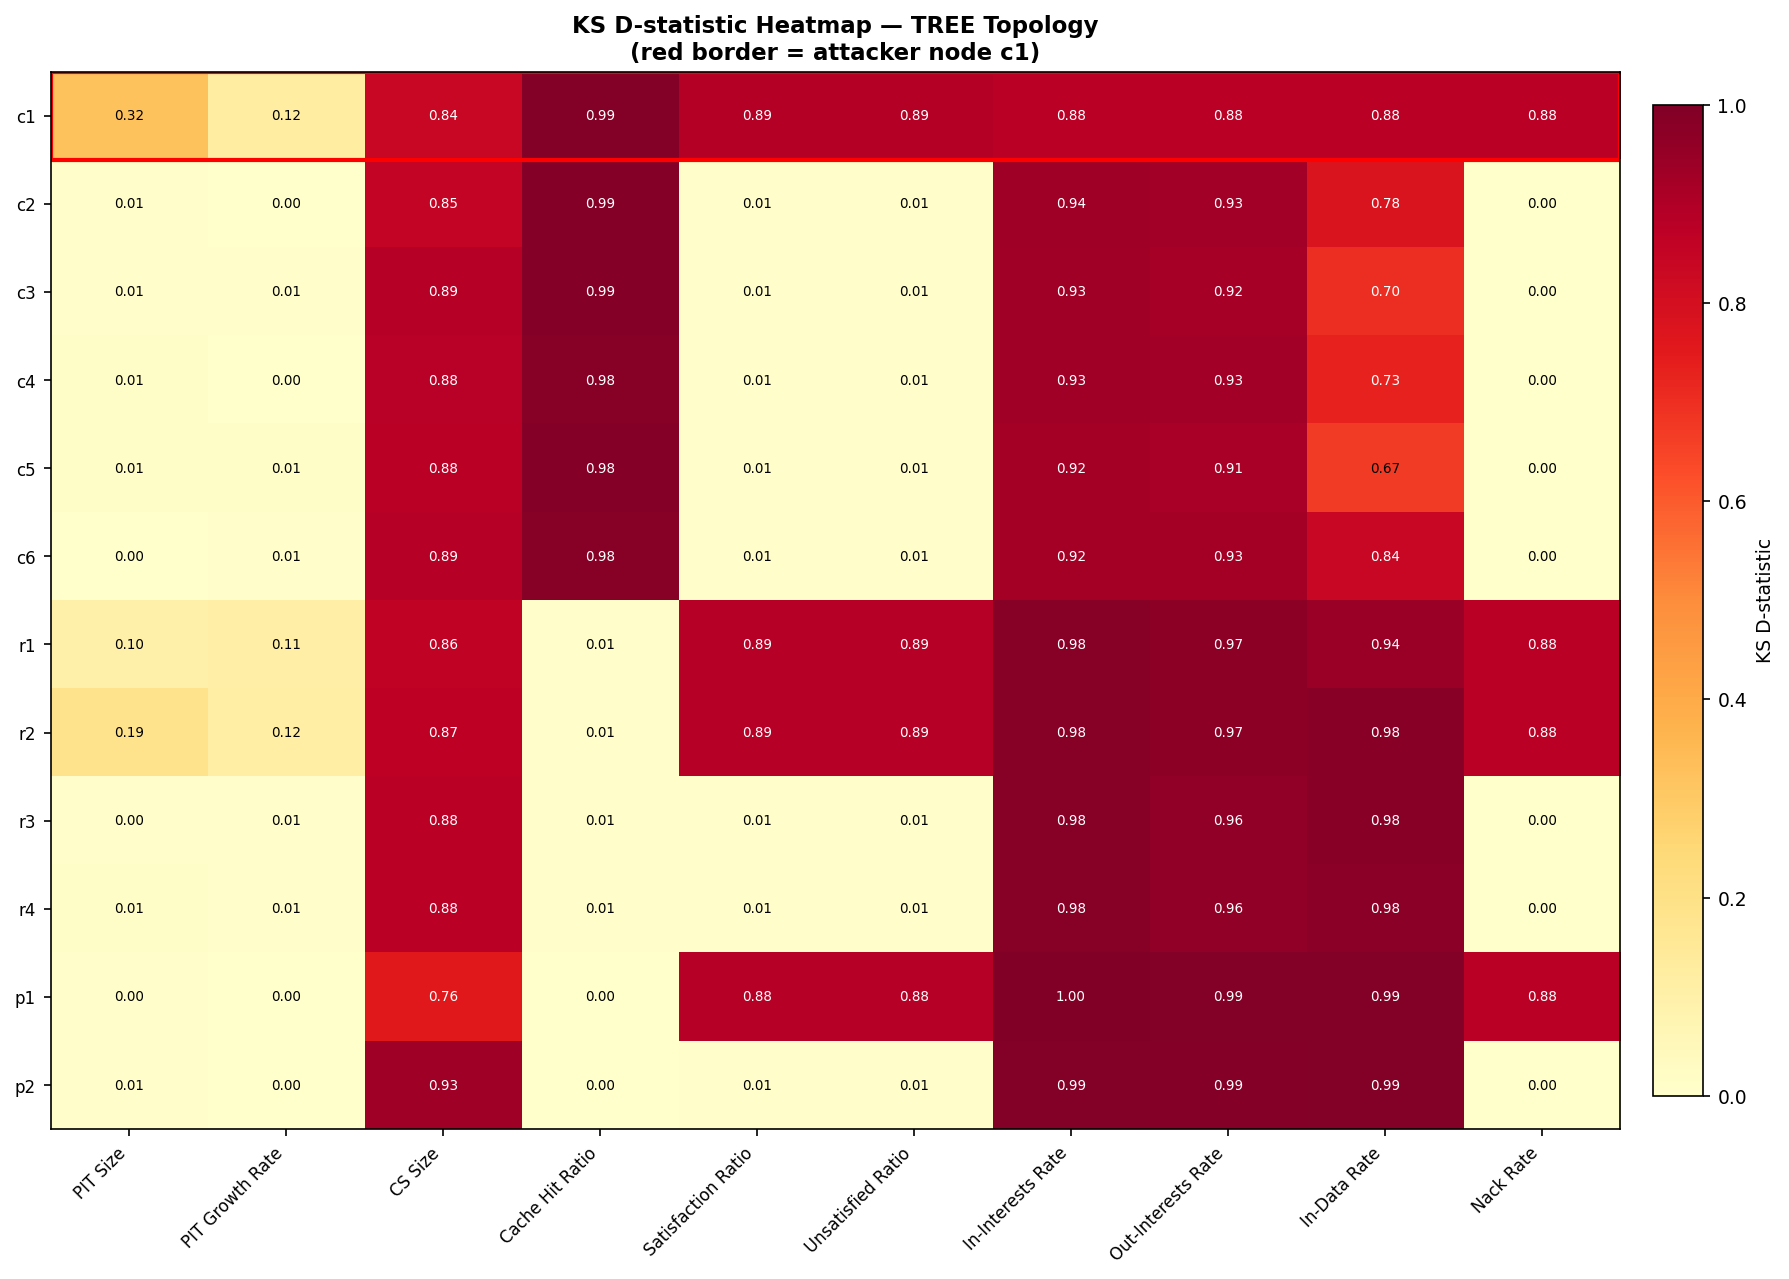

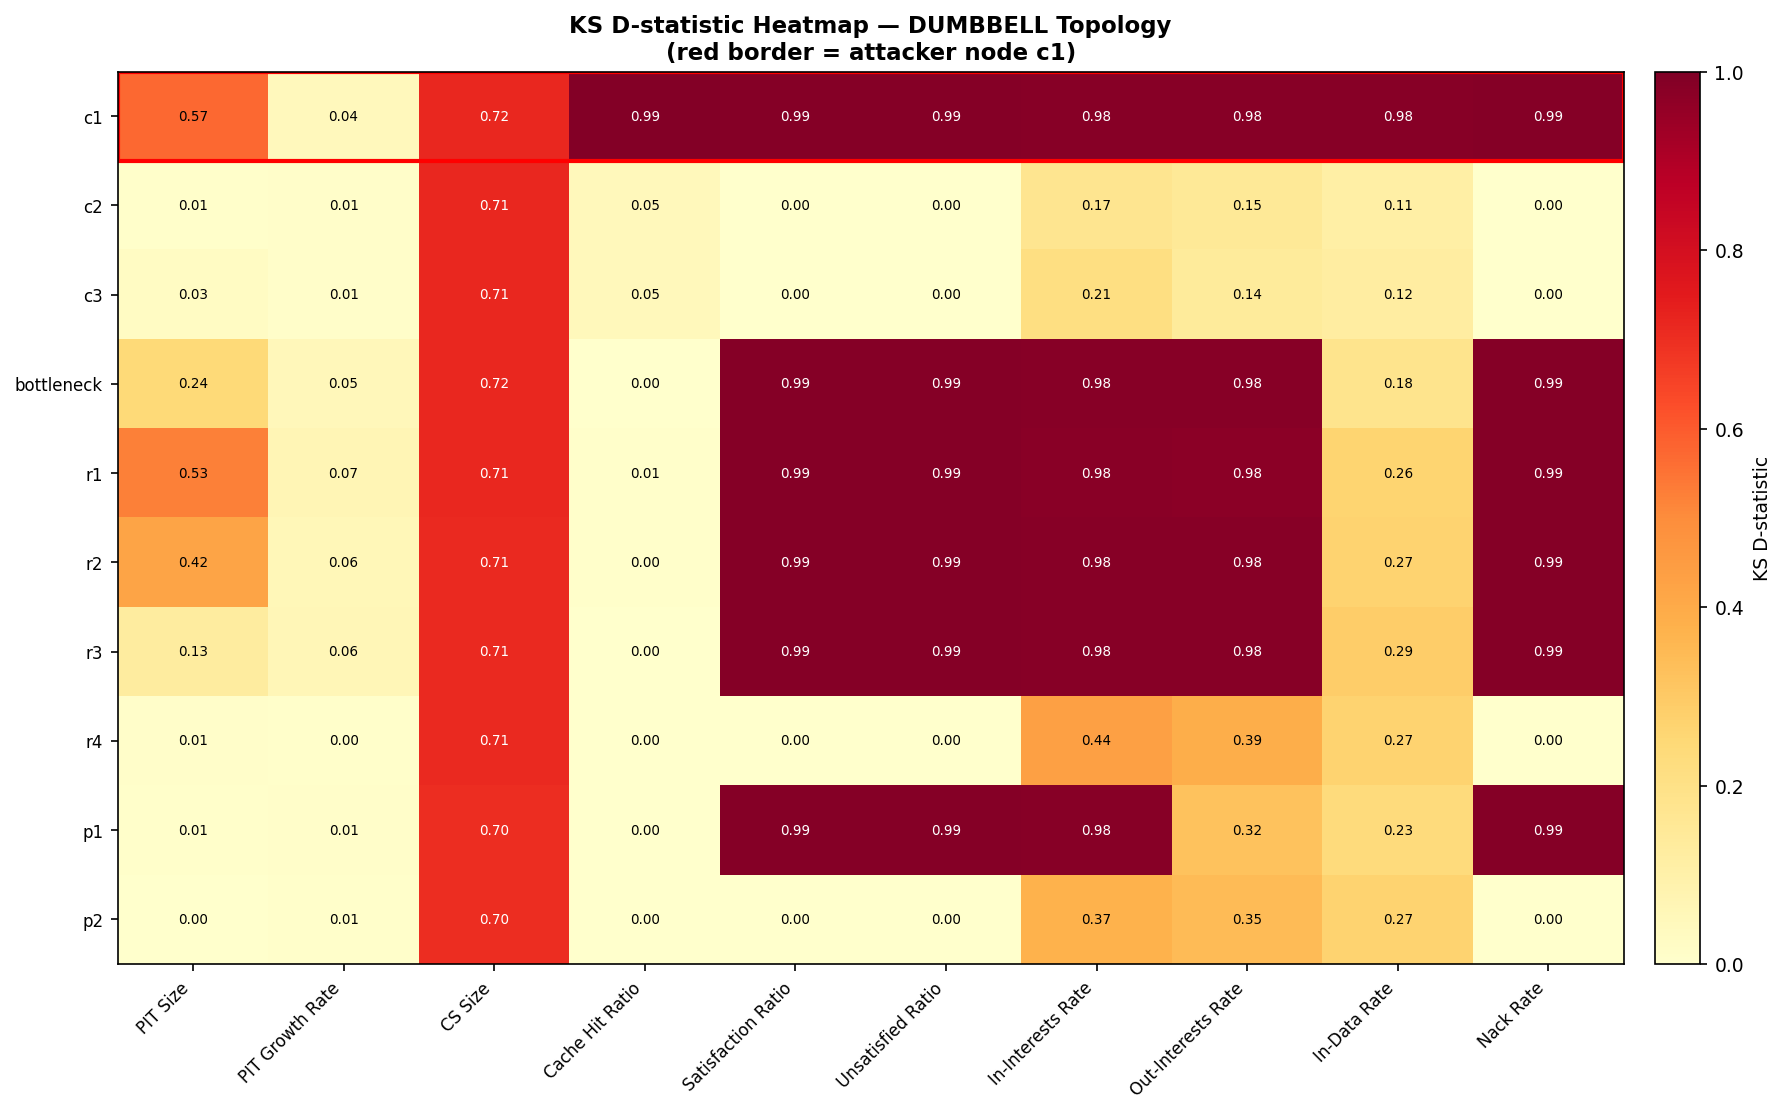

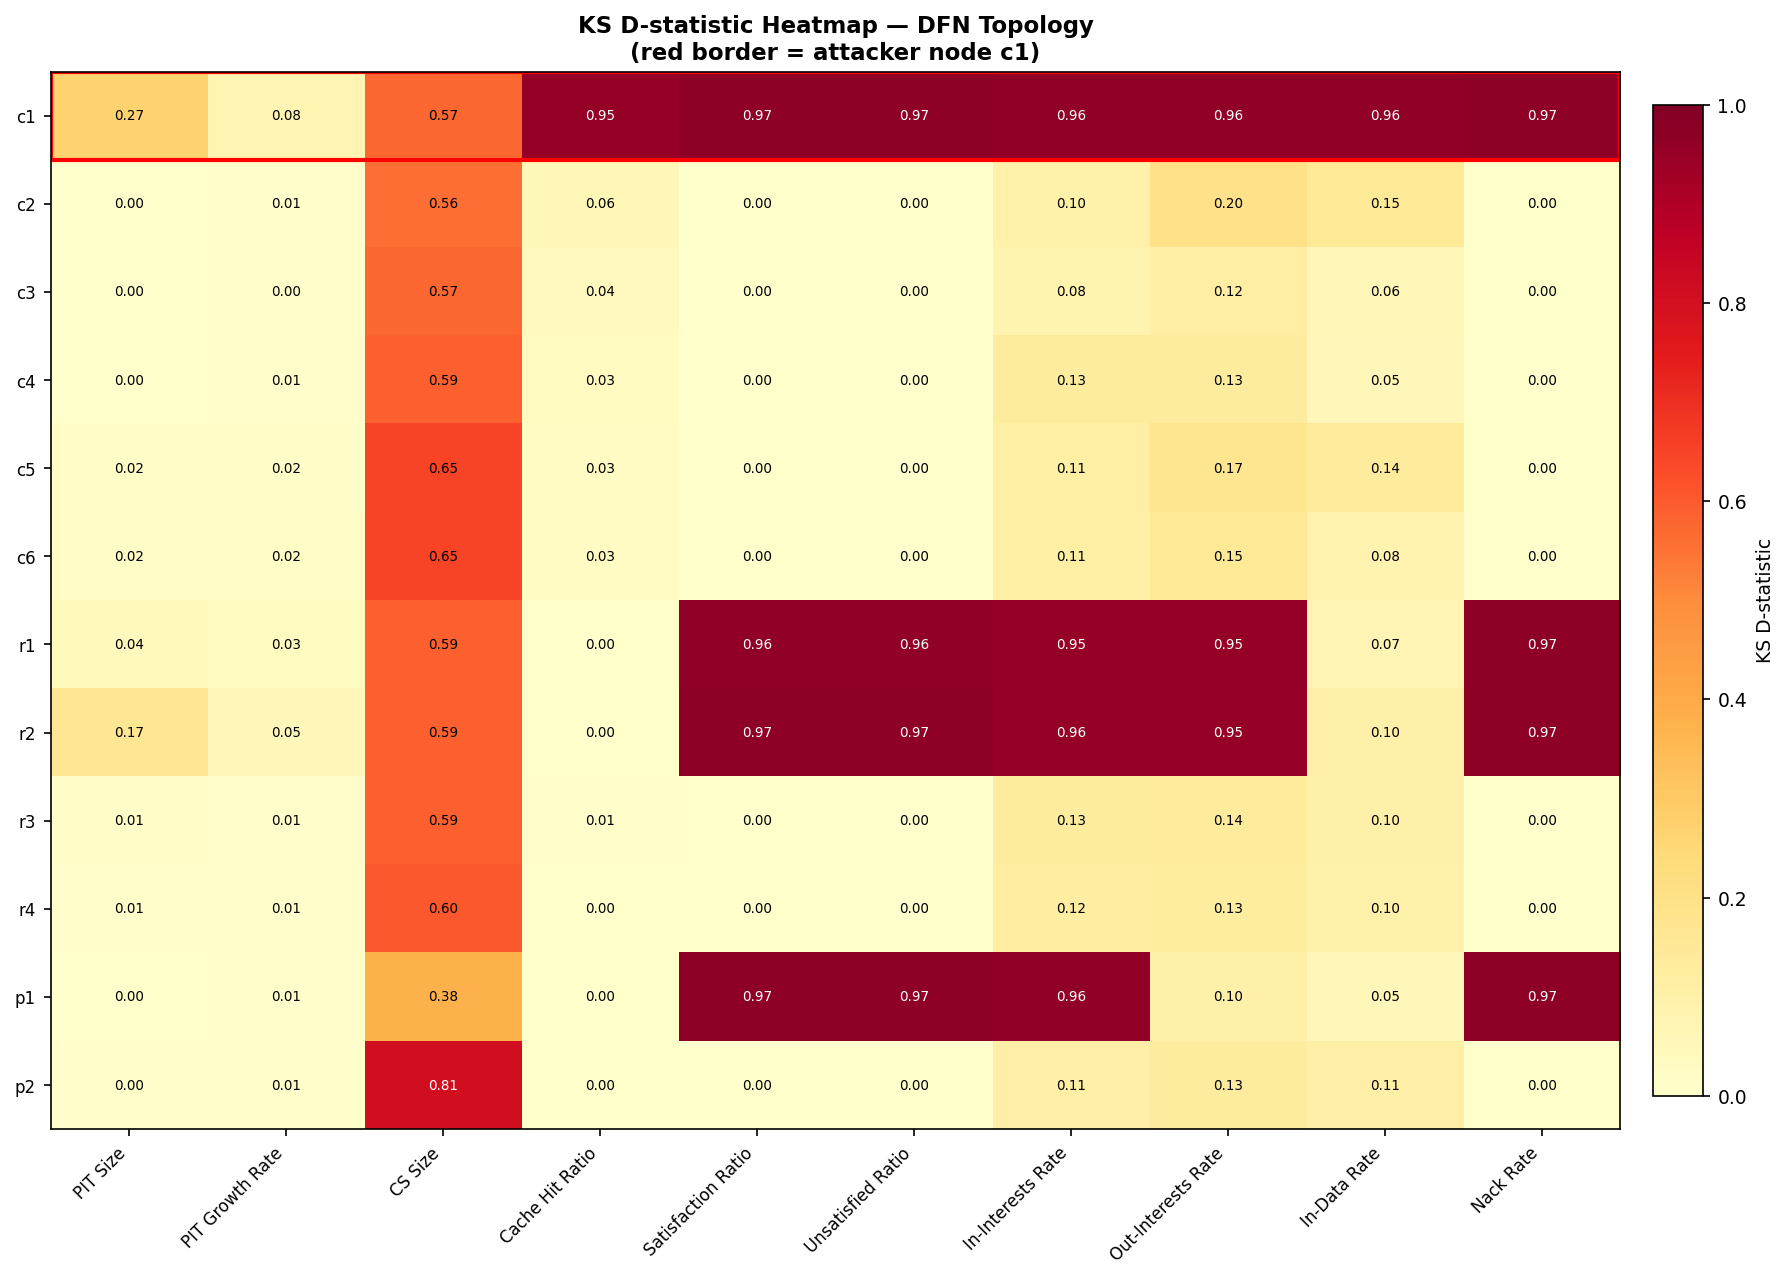

In [10]:
def plot_ks_heatmap(topo):
    d = data[topo]
    nodes = d["nodes"]
    df_topo = df_ks[df_ks["topology"] == topo]

    matrix = np.zeros((len(nodes), len(FEATURES)))
    for ri, node in enumerate(nodes):
        for ci, feat in enumerate(FEATURES):
            row = df_topo[(df_topo["node"] == node) & (df_topo["feature"] == feat)]
            if not row.empty:
                val = row["ks_stat"].values[0]
                matrix[ri, ci] = val if not np.isnan(val) else 0

    fig, ax = plt.subplots(figsize=(12, len(nodes) * 0.55 + 2))

    im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")

    for ri in range(len(nodes)):
        for ci in range(len(FEATURES)):
            ax.text(ci, ri, f"{matrix[ri, ci]:.2f}",
                    ha="center", va="center", fontsize=6.5,
                    color="black" if matrix[ri, ci] < 0.7 else "white")

    if ATTACKER in nodes:
        att_idx = nodes.index(ATTACKER)
        rect = Rectangle(
            (-0.5, att_idx - 0.5), len(FEATURES), 1,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_xticks(range(len(FEATURES)))
    ax.set_xticklabels([FEAT_LABELS[f] for f in FEATURES], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(nodes)))
    ax.set_yticklabels(nodes, fontsize=8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("KS D-statistic", fontsize=9)

    ax.set_title(
        f"KS D-statistic Heatmap — {topo.upper()} Topology\n(red border = attacker node c1)",
        fontsize=11, fontweight="bold"
    )

    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig_ks_heatmap_{topo}.png", bbox_inches="tight")
    plt.show()


for topo in data:
    plot_ks_heatmap(topo)

## Summary of Findings

### Strongest separating features

- **`satisfaction_ratio`** and **`unsatisfied_ratio`** show the highest KS D-statistics across all topologies and most nodes. Under IFA, the attacker floods the network with non-routable Interests, causing satisfaction ratios to collapse near zero while unsatisfied ratios spike to 1.

- **`nack_rate`** is also highly discriminative. The surge in NACKs during attack reflects the network's attempt to signal unreachable names back toward consumers.

### Attack propagation to backbone routers

Even nodes that are not directly involved in the attack (e.g., `r1`, `r2`) exhibit elevated **`pit_size`** and **`pit_growth_rate`** during IFA. Flooding Interest packets consume PIT entries throughout the forwarding path, making PIT-related features useful for detecting attack presence at intermediate nodes.

### Importance of per-node analysis

The attacker (`c1`) and benign consumers (`c2`–`c6`) show markedly different feature signatures:
- `c1` sees near-zero `satisfaction_ratio` and high `nack_rate` (its Interests are never satisfied)
- Benign consumers see reduced `satisfaction_ratio` due to congestion but retain some data flow
- Routers show PIT bloat and rising `nack_rate` as a secondary effect

This motivates **per-node anomaly detection** rather than aggregate traffic-level detection.